# Arquitectura y Modelo de Datos: Base de Datos **fraude_pagos**

## Diccionario de Entidades y Tablas

El modelo se compone de 13 tablas interconectadas que recogen desde la identidad y comportamiento de los usuarios hasta las señales de riesgo y patrones de fraude inyectados:

1. **cliente**: Datos maestros de los usuarios (identificador, nombre, correo electrónico y fecha de alta histórica).
2. **comercio**: Negocios o establecimientos receptores de los pagos, categorizados por sector (*categoría de negocio*), ciudad y país.
3. **dispositivo**: Terminales de los clientes desde los que se hacen los pagos online (móviles, ordenadores y tablets), con modelo y sistema operativo (*device fingerprinting*). Los pagos presenciales por datáfono no tienen dispositivo del cliente (dispositivo_id es NULL).
4. **metodo_pago**: Instrumentos financieros de los clientes (tarjetas de crédito/débito enmascaradas, entidad emisora, fecha de expiración y límite de crédito).
5. **canal_pago**: Puntos de acceso o pasarelas por las que se cursa la transacción (web, app o datáfono).
6. **cliente_dispositivo**: Tabla relacional que mapea la asociación histórica entre los clientes y los dispositivos desde los que interactúan.
7. **sesion**: Registro de las sesiones de acceso de los usuarios, incluyendo dirección IP, país de origen, uso de VPN/proxy, número de intentos de login y resultado.
8. **evento**: Acciones detalladas y secuenciales dentro de cada sesión (intentos de login fallidos, cambios de datos sensibles, inicio de pago, etc.).
9. **transaccion**: La tabla de hechos central del sistema. Registra cada operación comercial con su importe, moneda, tipo, estado (*aprobada* o *rechazada*) y la columna de etiqueta explícita **es_fraude** (0 para transacciones legítimas, 1 para fraudulentas).
10. **devolucion**: Reembolsos o contracargos (*chargebacks*) asociados a transacciones, distinguiendo entre devoluciones legítimas y abusivas/fraudulentas.
11. **alerta**: Sistema de señales de riesgo que identifica las transacciones sospechosas, vinculándolas a una puntuación de riesgo (*nota de riesgo*) y una fecha de detección.
12. **patron**: Catálogo descriptivo de los 9 tipos de esquemas de fraude inyectados de forma controlada en la simulación (ej. *card testing*, *smurfing*, *account takeover*, *pico de gasto*, *bot*, *bust_out*, etc.).
13. **analista**: Analistas antifraude que revisan las alertas (*human-in-the-loop*), con su nivel (junior/senior) y fecha de incorporación.

## Conexión y configuración

In [1]:
import os
import clickhouse_connect
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, '..')

AZUL = "#2b6cb0"        
AZULES = "Blues_r"       
CLASES = {"normal": "#9ecae1", "fraude": "#08306b"}

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

from config import HOST, PORT, USER, PASSWORD, DATABASE

client = clickhouse_connect.get_client(
    host=HOST, port=PORT, username=USER, password=PASSWORD, database=DATABASE
)
print(f"Conectado a la base de datos \"{DATABASE}\"")


Conectado a la base de datos "fraude_pagos"


## 1. Resumen general, filas por tabla

Una primera foto del volumen de cada tabla. 

In [2]:
TABLAS = ["cliente", "comercio", "dispositivo", "patron", "metodo_pago", "canal_pago","cliente_dispositivo", "sesion", "evento", "transaccion", "devolucion", "alerta", "analista"]

resumen = pd.DataFrame({
    "tabla": TABLAS,
    "filas": [client.command(f"SELECT count() FROM {t}") for t in TABLAS],
}).sort_values("filas", ascending=False)

resumen

,tabla,filas
8,evento,66321
9,transaccion,40363
7,sesion,28396
2,dispositivo,6500
6,cliente_dispositivo,4085
4,metodo_pago,3977
0,cliente,2000
11,alerta,1621
10,devolucion,432
5,canal_pago,46


In [3]:
from IPython.display import display

def generar_diccionario_datos_clickhouse(client, database_name):
    query = f"""
        SELECT 
            table AS tabla,
            name AS columna,
            type AS tipo_original
        FROM system.columns
        WHERE database = '{database_name}'
          AND table NOT IN ('transacciones_enriquecidas', 'alertas_enriquecidas')  
        ORDER BY table, position
    """
    df_cols = client.query_df(query)
    
    def clasificar_semantica(row):
        t = row['tipo_original'].lower()
        col = row['columna']
        
        # Identificación de variables binarias o de estado lógico
        if col in ['es_fraude', 'proxy_vpn'] or ('uint8' in t and ('es_' in col or 'is_' in col)):
            return 'Binaria (0 / 1 o Bool)'
        elif 'bool' in t:
            return 'Binaria (0 / 1 o Bool)'
        elif 'int' in t:
            return 'Numérica Entera (Integer)'
        elif 'float' in t or 'decimal' in t:
            return 'Numérica Real (Float / Decimal)'
        elif 'date' in t or 'time' in t:
            return 'Fecha / Temporal (DateTime)'
        elif 'string' in t:
            return 'Categórica / Texto (String)'
        else:
            return 'Especial / Nullable'

    df_cols['tipo_semantico'] = df_cols.apply(clasificar_semantica, axis=1)
    return df_cols

df_diccionario_datos = generar_diccionario_datos_clickhouse(client, DATABASE)
print(f"Total de variables catalogadas en '{DATABASE}': {len(df_diccionario_datos)}")
display(df_diccionario_datos.head(15))

Total de variables catalogadas en 'fraude_pagos': 128


,tabla,columna,tipo_original,tipo_semantico
0,alerta,alerta_id,UInt32,Numérica Entera (Integer)
1,alerta,transaccion_id,UInt32,Numérica Entera (Integer)
2,alerta,origen,LowCardinality(String),Categórica / Texto (String)
3,alerta,patron_id,Nullable(UInt32),Numérica Entera (Integer)
4,alerta,nota_riesgo,Float32,Numérica Real (Float / Decimal)
5,alerta,fecha,DateTime,Fecha / Temporal (DateTime)
6,alerta,estado,LowCardinality(String),Categórica / Texto (String)
7,alerta,analista_id,Nullable(UInt32),Numérica Entera (Integer)
8,alerta,fecha_revision,Nullable(DateTime),Fecha / Temporal (DateTime)
9,alerta,veredicto,LowCardinality(Nullable(String)),Categórica / Texto (String)


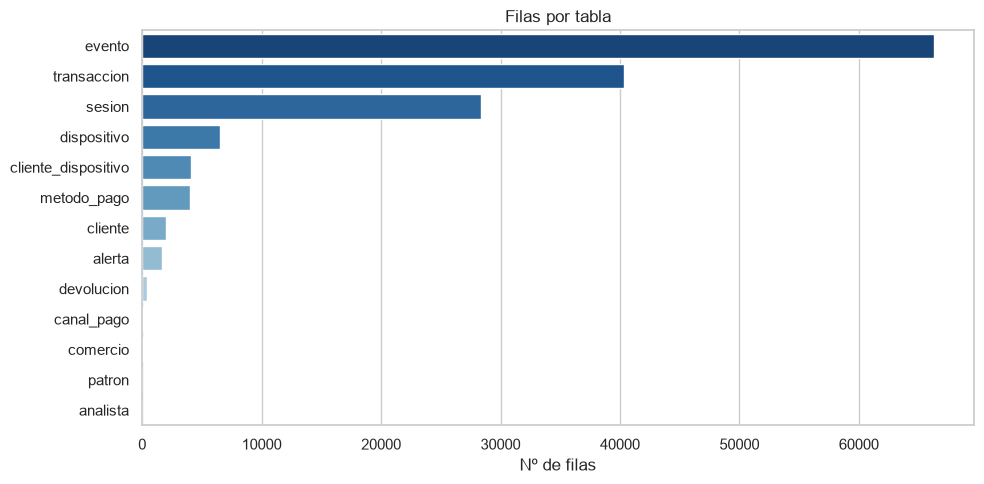

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=resumen, x="filas", y="tabla", hue="tabla", palette = 'Blues_r', legend=False, ax=ax)
ax.set_title("Filas por tabla")
ax.set_xlabel("Nº de filas")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 1.1 Estadística descriptiva

Resumen numérico de las variables principales, sobre la tabla transacciones_enriquecidas (una fila por transacción con todo unido). Se muestra la media, la mediana, porque con distribuciones muy asimétricas como el importe la media se va hacia los valores extremos y no representa a la transacción típica. La asimetría indica cuánto se alarga la cola: 0 es simétrica y valores altos indican una cola larga a la derecha.

In [5]:
df_te = client.query_df("""
    SELECT cantidad, limite_credito, num_intentos_login, proxy_vpn, es_fraude,
           toHour(timestamp) AS hora,
           dateDiff('day', fecha_alta, timestamp) AS dias_desde_alta,
           canal_tipo, metodo_tipo, moneda, estado, metodo_autenticacion, tipo_operacion,
           categoria_negocio, cliente_pais, ip_pais, dispositivo_tipo, sistema_operativo
    FROM transacciones_enriquecidas
""")
for col in ["cantidad", "limite_credito"]:
    df_te[col] = df_te[col].astype(float)

NUMERICAS = ["cantidad", "limite_credito", "num_intentos_login", "hora", "dias_desde_alta"]

desc = df_te[NUMERICAS].describe().T
desc["mediana"] = df_te[NUMERICAS].median()
desc["asimetria"] = df_te[NUMERICAS].skew()
desc["nulos_%"] = df_te[NUMERICAS].isna().mean() * 100
desc = desc[["count", "nulos_%", "mean", "mediana", "std", "min", "25%", "75%", "max", "asimetria"]]
desc.round(2)

,count,nulos_%,mean,mediana,std,min,25%,75%,max,asimetria
cantidad,40363.0,0.00,67.945141,30.17,417.263241,0.4,17.04,53.81,13845.27,24.31
limite_credito,23507.0,41.76,8122.1651,8153.0,4102.882178,1001.0,4594.0,11693.0,14986.0,-0.01
num_intentos_login,30849.0,23.57,1.194528,1.0,0.610348,1.0,1.0,1.0,7.0,4.08
hora,40363.0,0.00,13.671779,14.0,5.744739,0.0,10.0,18.0,23.0,-0.46
dias_desde_alta,40363.0,0.00,443.216634,441.0,209.344653,3.0,272.0,621.0,874.0,-0.02


La cantidad es muy asimétrica (asimetría de 24): la media (67,95 €) es más del doble de la mediana (30,17 €) porque unas pocas transacciones muy grandes tiran de ella hacia arriba, y la desviación típica (417 €) es mucho mayor que la media. Por eso es mejor describirla con la mediana y los cuartiles (el 50 % central está entre 17 y 54 €) y visualizarla en escala logarítmica.

Los intentos de login también son asimétricos: casi todas las sesiones tienen 1 intento. Los nulos son los esperados: límite de crédito en las tarjetas de débito (41,8 %) e intentos de login en los pagos presenciales (23,6 %).

La hora y la antigüedad del cliente son bastante simétricas.

### Por clase (normal vs. fraude)

La misma tabla separada por clase, con la mediana y la media de cada variable. 

In [6]:
df_te["clase"] = df_te["es_fraude"].map({1: "fraude", 0: "normal"})
por_clase = df_te.groupby("clase")[NUMERICAS].agg(["median", "mean"]).T.unstack()
por_clase.columns = [f"{clase}_{estad}" for clase, estad in por_clase.columns]
por_clase = por_clase[["normal_median", "fraude_median", "normal_mean", "fraude_mean"]]
por_clase["ratio_medianas"] = por_clase["fraude_median"] / por_clase["normal_median"]
por_clase.round(2)

,normal_median,fraude_median,normal_mean,fraude_mean,ratio_medianas
cantidad,29.7,239.71,45.968304,1174.53201,8.071044
limite_credito,8143.0,8621.0,8118.274767,8316.218615,1.058701
num_intentos_login,1.0,1.0,1.189835,1.374046,1.0
hora,14.0,6.0,13.771862,8.632316,0.428571
dias_desde_alta,441.0,439.5,443.156707,446.234097,0.996599


La cantidad es la variable que más cambia: la mediana del fraude (239,71 €) es unas 8 veces la de las normales (29,70 €).

La hora también cambia mucho: la mediana del fraude son las 6 h y la de las normales las 14 h.

El límite de crédito, la antigüedad del cliente y los intentos de login apenas cambian entre clases.

### Variables categóricas

Para cada variable categórica: cuántos valores distintos tiene, cuál es el más frecuente y qué porcentaje de las transacciones representa. Sirve para detectar variables que no aportan nada (un solo valor) o con demasiadas categorías.

In [7]:
CATEGORICAS = ["canal_tipo", "metodo_tipo", "moneda", "estado", "metodo_autenticacion", "tipo_operacion",
               "categoria_negocio", "cliente_pais", "ip_pais", "dispositivo_tipo", "sistema_operativo"]
resumen_cat = pd.DataFrame({
    "valores_distintos": df_te[CATEGORICAS].nunique(),
    "mas_frecuente": df_te[CATEGORICAS].mode().iloc[0],
    "pct_mas_frecuente": [df_te[c].value_counts(normalize=True).iloc[0] * 100 for c in CATEGORICAS],
    "nulos_%": df_te[CATEGORICAS].isna().mean() * 100,
})
resumen_cat.round(2)

,valores_distintos,mas_frecuente,pct_mas_frecuente,nulos_%
canal_tipo,3,app,54.12,0.00
metodo_tipo,2,credito,58.24,0.00
moneda,1,EUR,100.00,0.00
estado,2,aprobada,96.40,0.00
metodo_autenticacion,5,3D-secure,53.60,0.00
tipo_operacion,1,compra,100.00,0.00
categoria_negocio,14,deporte,10.70,0.00
cliente_pais,10,España,47.49,0.00
ip_pais,22,España,46.12,23.57
dispositivo_tipo,3,movil,59.95,23.57


moneda (solo EUR) y tipo_operacion (solo compra) tienen un único valor, así que no aportan información y no se usarán como variables en los modelos. ip_pais, dispositivo_tipo y sistema_operativo tienen un 23,6 % de nulos, que son los pagos presenciales. ip_pais tiene 22 valores distintos frente a los 10 de cliente_pais: la diferencia son las conexiones desde otros países.

### Correlaciones

Correlación de Spearman entre las variables numéricas y la etiqueta es_fraude. Se usa Spearman y no Pearson porque el importe es muy asimétrico y Spearman trabaja con el orden de los valores, así que no le afectan tanto los extremos. proxy_vpn se incluye como 0/1.

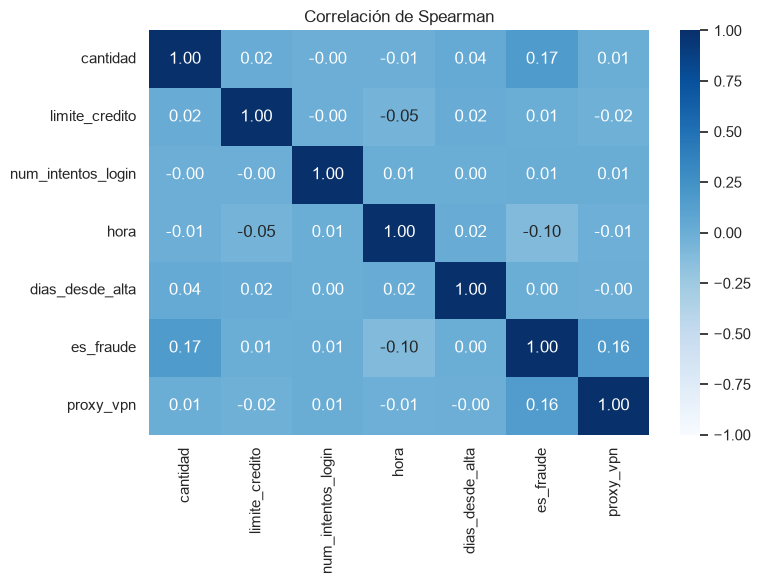

cantidad              0.167
proxy_vpn             0.158
hora                 -0.102
num_intentos_login    0.010
limite_credito        0.007
dias_desde_alta       0.002
Name: es_fraude, dtype: float64

In [8]:
corr_df = df_te[NUMERICAS + ["es_fraude"]].copy()
corr_df["proxy_vpn"] = df_te["proxy_vpn"].astype(float)
corr = corr_df.corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación de Spearman")
plt.tight_layout()
plt.show()

corr["es_fraude"].drop("es_fraude").sort_values(key=abs, ascending=False).round(3)

Ninguna variable tiene una correlación fuerte con es_fraude: la más alta es el importe (0,17), seguida de la VPN (0,16) y la hora (-0,10, negativa porque el fraude se concentra en horas bajas, de madrugada). El número de intentos de login, la antigüedad y el límite de crédito están prácticamente en 0. Hay que tener en cuenta que la correlación solo mide relaciones monótonas y una variable a la vez: el card testing (importes muy bajos) y el pico de gasto (importes muy altos) van en direcciones opuestas y se compensan. Por eso una correlación baja no significa que la variable no sirva, y los modelos que combinan variables pueden detectar lo que la correlación no ve.

## 2.Transaccion

### 2.1 Distribución de importes (cantidades)

A la izquierda solo se muestran las transacciones hasta el percentil 99, para que se vea bien dónde se concentra la mayoría. A la derecha está todo el rango en escala logarítmica, donde aparecen también los importes muy altos. En los dos gráficos el fraude está apilado encima de las transacciones normales, en azul oscuro.

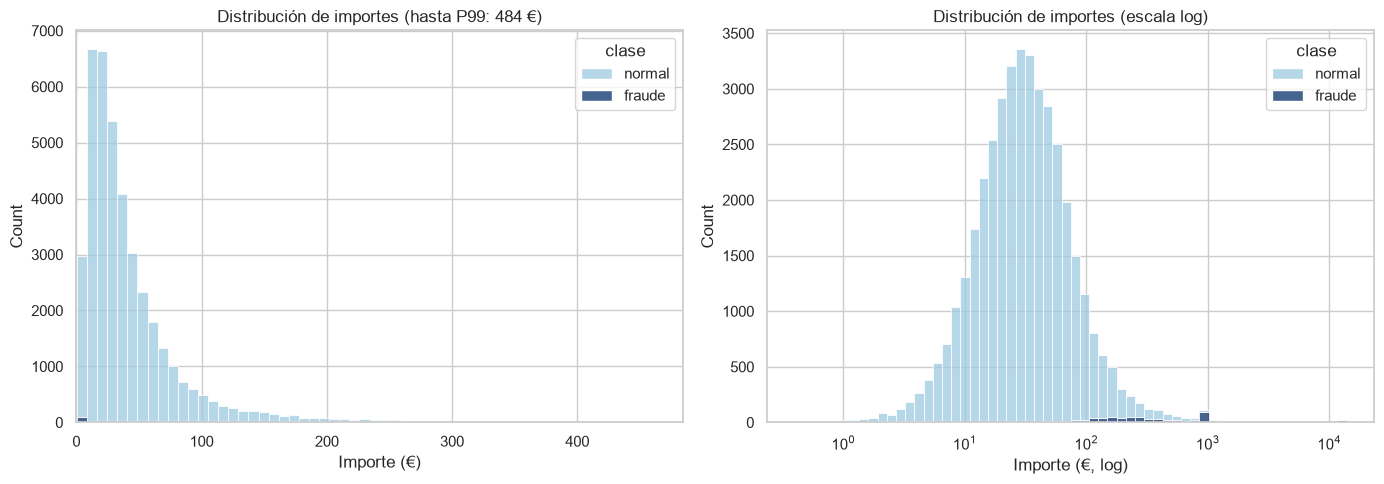

Importe máximo: 13,845.27 €
Transacciones por encima del P99 (484.39 €): 404


In [9]:
df_txn = client.query_df("SELECT transaccion_id, metodo_id, cantidad, estado, tipo_operacion, es_fraude, timestamp FROM transaccion")
df_txn["cantidad"] = df_txn["cantidad"].astype(float)
df_txn["clase"] = df_txn["es_fraude"].map({1: "fraude", 0: "normal"})

CUTOFF = df_txn["cantidad"].quantile(0.99)  

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_txn[df_txn["cantidad"] <= CUTOFF], x="cantidad", hue="clase",
             hue_order=["normal", "fraude"], palette=CLASES, multiple="stack", bins=60, ax=axes[0])
axes[0].set_xlim(0, CUTOFF)
axes[0].set_title(f"Distribución de importes (hasta P99: {CUTOFF:,.0f} €)")
axes[0].set_xlabel("Importe (€)")


sns.histplot(data=df_txn, x="cantidad", hue="clase", hue_order=["normal", "fraude"],
             palette=CLASES, multiple="stack", bins=60, log_scale=True, ax=axes[1])
axes[1].set_title("Distribución de importes (escala log)")
axes[1].set_xlabel("Importe (€, log)")

plt.tight_layout()
plt.show()

n_por_encima = (df_txn["cantidad"] > CUTOFF).sum()
print(f"Importe máximo: {df_txn['cantidad'].max():,.2f} €")
print(f"Transacciones por encima del P99 ({CUTOFF:,.2f} €): {n_por_encima}")


La mayoría de transacciones son de importe bajo: el percentil 99 está en 484,39 € y solo 404 transacciones lo superan. El máximo es 13.845,27 €. En escala logarítmica se ve que el fraude aparece en los dos extremos: importes muy bajos (card testing, alrededor de 2-3 €) e importes muy altos (smurfing cerca de 1.000 €, bust-out cerca del límite de crédito). Pero una parte del fraude cae en la misma zona que las transacciones normales, así que el importe por sí solo no basta.

### 2.2 Estado y tipo de operación
A la izquierda, el porcentaje de transacciones aprobadas y rechazadas dentro de cada clase. Se usan porcentajes porque hay muchas menos transacciones de fraude y con conteos no se verían. A la derecha, el reparto por tipo de operación.

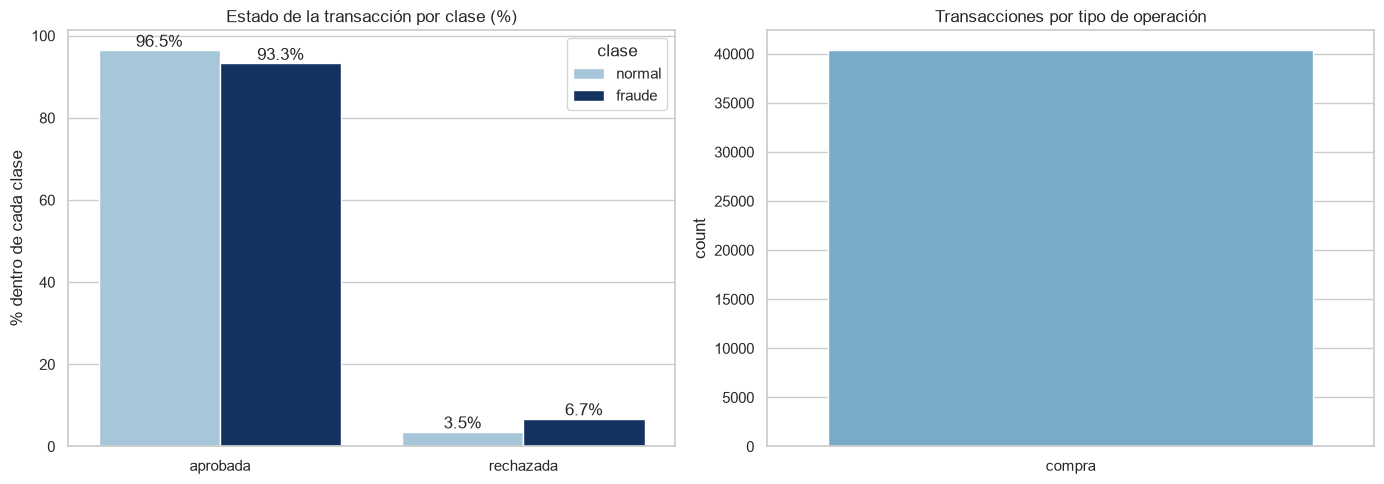

estado,aprobada,rechazada
clase,,
fraude,93.26,6.74
normal,96.46,3.54


In [10]:
estado_clase = (pd.crosstab(df_txn["clase"], df_txn["estado"], normalize="index")
                  .mul(100).round(2)
                  .reset_index()
                  .melt(id_vars="clase", var_name="estado", value_name="pct"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=estado_clase, x="estado", y="pct", hue="clase",
            hue_order=["normal", "fraude"], palette=CLASES, ax=axes[0])
axes[0].set_title("Estado de la transacción por clase (%)")
axes[0].set_ylabel("% dentro de cada clase")
axes[0].set_xlabel("")
for cont in axes[0].containers:
    axes[0].bar_label(cont, fmt="%.1f%%")

sns.countplot(data=df_txn, x="tipo_operacion", hue="tipo_operacion", palette=AZULES, legend=False,
              order=df_txn["tipo_operacion"].value_counts().index, ax=axes[1])
axes[1].set_title("Transacciones por tipo de operación")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

pd.crosstab(df_txn["clase"], df_txn["estado"], normalize="index").mul(100).round(2)

Se rechaza el 6,74 % de las transacciones de fraude frente al 3,54 % de las normales, casi el doble. El estado es una señal útil, aunque débil: más del 93 % del fraude se aprueba, y el 3,5 % de rechazos normales también existe.

### 2.3 Transacciones por día
Arriba, el total de transacciones diarias con su média movil. Abajo, solo las de fraude, en un gráfico aparte porque con unas 4 al día no se verían junto al total.


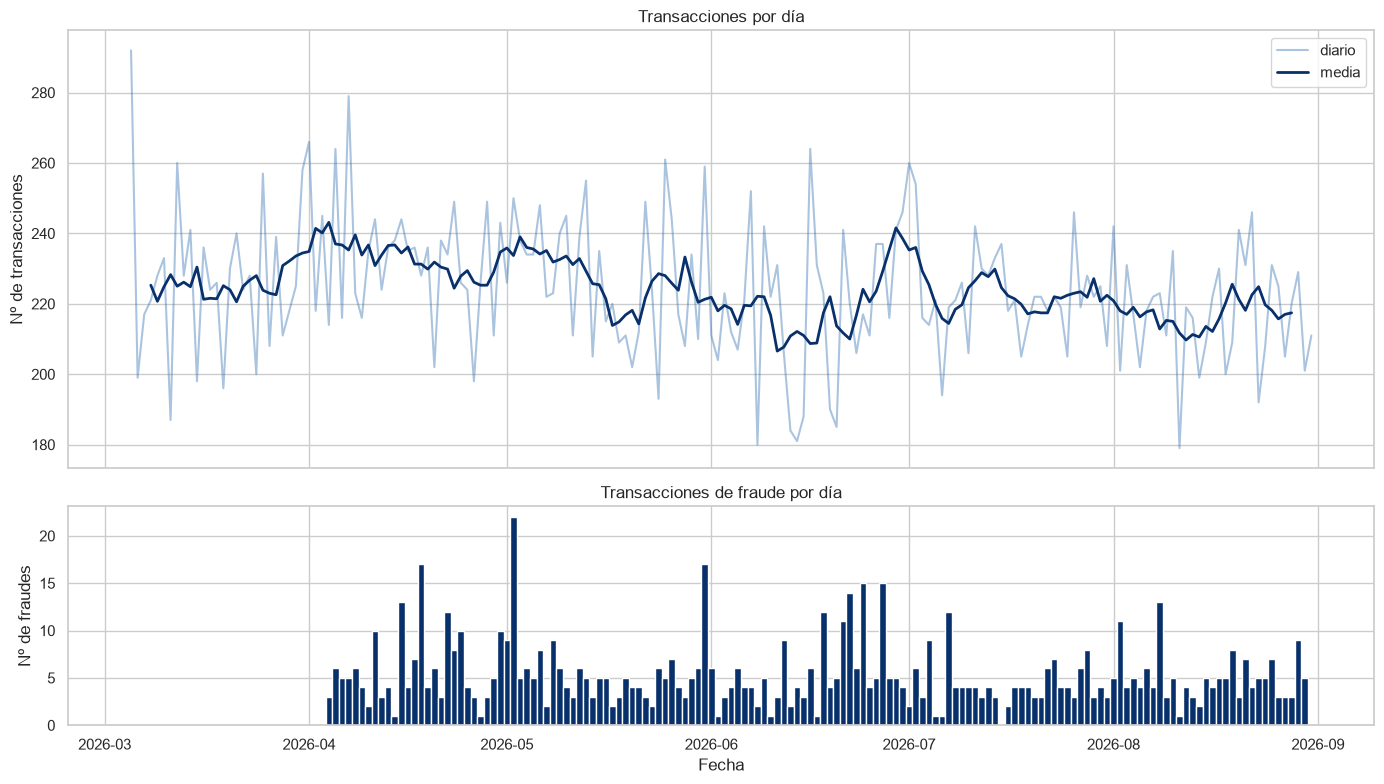

Total  -> media diaria: 224.2    mínimo: 179    máximo: 292
Fraude -> media diaria: 4.4   máximo: 22 (2026-05-02)


In [11]:
df_txn["fecha"] = pd.to_datetime(df_txn["timestamp"]).dt.date
por_dia = df_txn.groupby(["fecha", "clase"]).size().unstack(fill_value=0)
por_dia["total"] = por_dia["normal"] + por_dia["fraude"]
media_7d = por_dia["total"].rolling(7, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

axes[0].plot(por_dia.index, por_dia["total"], color=AZUL, alpha=0.4, label="diario")
axes[0].plot(por_dia.index, media_7d, color="#08306b", linewidth=2, label="media")
axes[0].set_title("Transacciones por día")
axes[0].set_ylabel("Nº de transacciones")
axes[0].legend()

axes[1].bar(por_dia.index, por_dia["fraude"], color=CLASES["fraude"], width=1)
axes[1].set_title("Transacciones de fraude por día")
axes[1].set_ylabel("Nº de fraudes")
axes[1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

print(f"Total  -> media diaria: {por_dia['total'].mean():.1f}    mínimo: {por_dia['total'].min()}    máximo: {por_dia['total'].max()}")
print(f"Fraude -> media diaria: {por_dia['fraude'].mean():.1f}   máximo: {por_dia['fraude'].max()} ({por_dia['fraude'].idxmax()})")

Hay una media de 224,2 transacciones al día (entre 179 y 292) y unas 4,4 de fraude. El fraude no sigue una tendencia en el tiempo: aparece repartido a lo largo de todo el periodo, con picos puntuales (máximo de 22 el 2 de mayo de 2026) que corresponden a casos que generan varias transacciones seguidas, como el card testing.

### 2.4 Transacciones por cliente

La tabla transaccion no tiene cliente_id, así que hay que pasar por metodo_pago (en el esquema cliente y transaccion no están relacionadas directamente). Para cada cliente se calcula el número de transacciones, el importe total en los 6 meses y cuántas de sus transacciones son fraude. Se separan los clientes con al menos un fraude del resto para ver si tienen más actividad o gastan más. Los histogramas están en densidad porque hay muchos menos clientes con fraude.

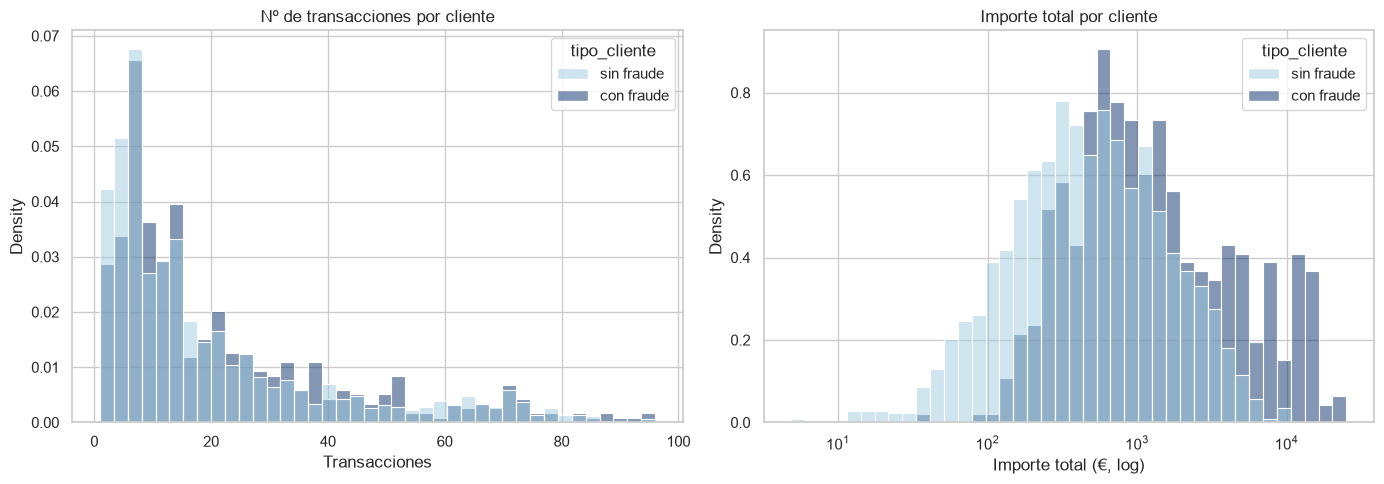

tipo_cliente
sin fraude    1495
con fraude     500 



tipo_cliente           con fraude  sin fraude
n_transacciones count      500.00     1495.00
                mean        21.75       19.72
                std         20.30       19.89
                min          1.00        1.00
                25%          7.00        6.00
                50%         14.00       12.00
                75%         30.00       26.00
                max         95.00       96.00
importe_total   count      500.00     1495.00
                mean      2812.41      893.82
                std       4035.98     1164.70
                min         40.57        4.88
                25%        494.20      198.80
                50%       1037.96      462.20
                75%       3124.44     1093.24
                max      25050.94    10273.34

In [12]:
txn_por_cliente = client.query_df("""
    SELECT m.cliente_id,
           count() AS n_transacciones,
           round(sum(t.cantidad), 2) AS importe_total,
           countIf(t.es_fraude = 1) AS n_fraudes
    FROM transaccion t
    JOIN metodo_pago m ON t.metodo_id = m.metodo_id
    GROUP BY m.cliente_id
""")
txn_por_cliente["importe_total"] = txn_por_cliente["importe_total"].astype(float)
txn_por_cliente["tipo_cliente"] = txn_por_cliente["n_fraudes"].gt(0).map({True: "con fraude", False: "sin fraude"})

COLORES_CLI = {"sin fraude": CLASES["normal"], "con fraude": CLASES["fraude"]}
ORDEN_CLI = ["sin fraude", "con fraude"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=txn_por_cliente, x="n_transacciones", hue="tipo_cliente", hue_order=ORDEN_CLI,
             palette=COLORES_CLI, stat="density", common_norm=False, bins=40, ax=axes[0])
axes[0].set_title("Nº de transacciones por cliente")
axes[0].set_xlabel("Transacciones")

sns.histplot(data=txn_por_cliente, x="importe_total", hue="tipo_cliente", hue_order=ORDEN_CLI,
             palette=COLORES_CLI, stat="density", common_norm=False, bins=40, log_scale=True, ax=axes[1])
axes[1].set_title("Importe total por cliente")
axes[1].set_xlabel("Importe total (€, log)")

plt.tight_layout()
plt.show()

print(txn_por_cliente["tipo_cliente"].value_counts().to_string(), "\n")
txn_por_cliente.groupby("tipo_cliente")[["n_transacciones", "importe_total"]].describe().T.round(2)

500 de los 2.000 clientes (25 %) tienen al menos una transacción de fraude. En número de transacciones apenas se diferencian del resto (mediana de 14 frente a 12), pero su importe total es mayor (mediana de 1.037,96 € frente a 462,20 €). Esa diferencia viene sobre todo de las propias transacciones fraudulentas, que se incluyen en el total. El cliente más activo tiene 96 transacciones en 6 meses, un volumen realista.

## 3. Cliente

### 3.1 Antigüedad de los clientes

cliente.fecha_alta es la fecha de alta (como mucho 700 días antes del inicio del dataset). La antigüedad se calcula respecto a la primera transacción del dataset y no respecto a hoy, para que no cambie según cuándo se ejecute el notebook. Se comparan los clientes con al menos un fraude con el resto, porque algunos patrones suelen darse en cuentas recientes.

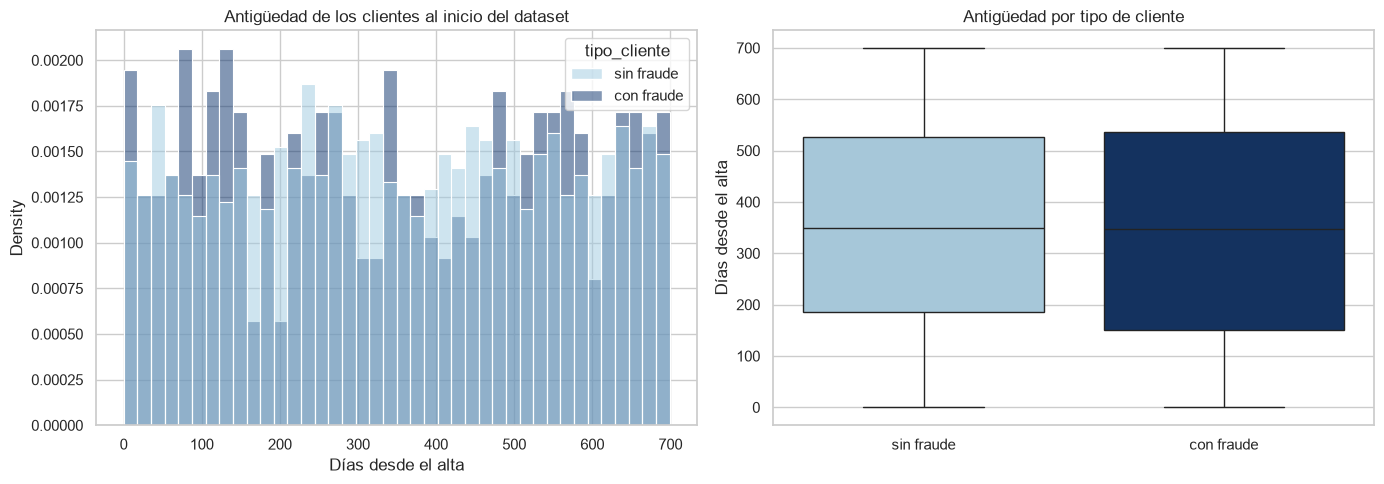

Inicio del dataset: 2026-03-05



,n,mediana,media
tipo_cliente,,,
con fraude,500,347.5,350.4
sin fraude,1500,350.0,353.7


In [13]:
df_cli = client.query_df("SELECT cliente_id, fecha_alta FROM cliente")

inicio_dataset = pd.to_datetime(df_txn["timestamp"]).min()
df_cli["antiguedad_dias"] = (inicio_dataset - pd.to_datetime(df_cli["fecha_alta"])).dt.days

df_cli = df_cli.merge(txn_por_cliente[["cliente_id", "tipo_cliente"]], on="cliente_id", how="left")
df_cli["tipo_cliente"] = df_cli["tipo_cliente"].fillna("sin fraude")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_cli, x="antiguedad_dias", hue="tipo_cliente", hue_order=ORDEN_CLI,
             palette=COLORES_CLI, stat="density", common_norm=False, bins=40, ax=axes[0])
axes[0].set_title("Antigüedad de los clientes al inicio del dataset")
axes[0].set_xlabel("Días desde el alta")

sns.boxplot(data=df_cli, x="tipo_cliente", y="antiguedad_dias", hue="tipo_cliente",
            order=ORDEN_CLI, palette=COLORES_CLI, legend=False, ax=axes[1])
axes[1].set_title("Antigüedad por tipo de cliente")
axes[1].set_xlabel("")
axes[1].set_ylabel("Días desde el alta")

plt.tight_layout()
plt.show()

print(f"Inicio del dataset: {inicio_dataset:%Y-%m-%d}\n")
df_cli.groupby("tipo_cliente")["antiguedad_dias"].agg(n="count", mediana="median", media="mean").round(1)

La antigüedad no distingue el fraude: los clientes con fraude tienen una mediana de 347,5 días desde el alta y el resto 350. En este dataset la fecha de alta no influye en qué clientes sufren fraude.

### 3.2 Métodos de pago y dispositivos por cliente

Cuántos métodos de pago y dispositivos personales tiene cada cliente en promedio.

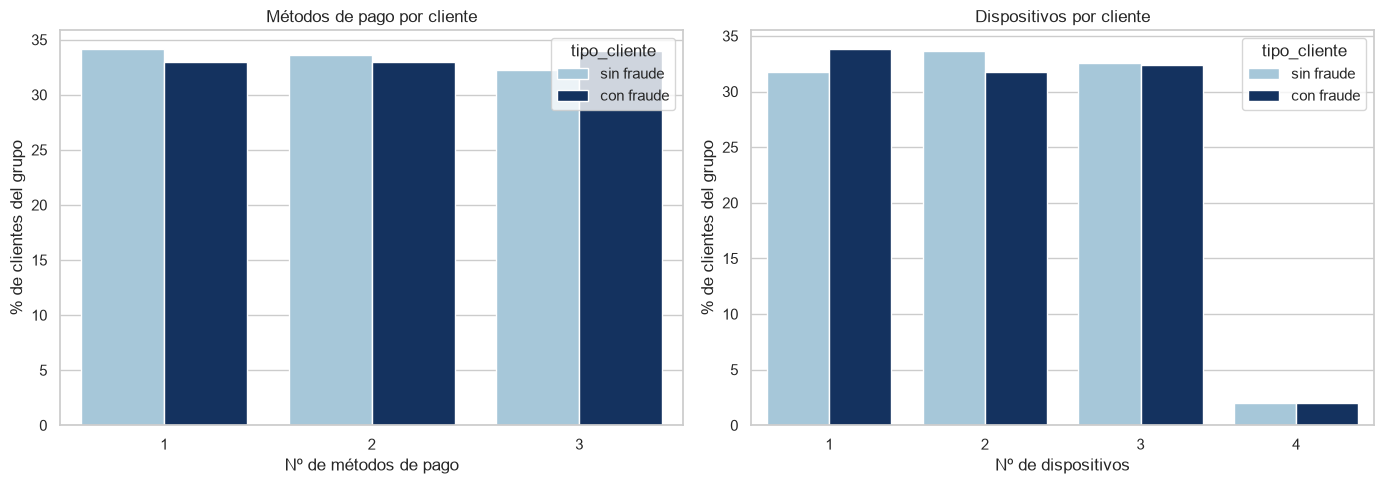

,n_metodos,n_dispositivos
tipo_cliente,,
con fraude,2.01,2.03
sin fraude,1.98,2.05


In [14]:
metodos_por_cliente = client.query_df("SELECT cliente_id, count() AS n_metodos FROM metodo_pago GROUP BY cliente_id")
disp_por_cliente = client.query_df("SELECT cliente_id, count() AS n_dispositivos FROM cliente_dispositivo GROUP BY cliente_id")

df_cli_act = (df_cli[["cliente_id", "tipo_cliente"]]
              .merge(metodos_por_cliente, on="cliente_id", how="left")
              .merge(disp_por_cliente, on="cliente_id", how="left")
              .fillna({"n_metodos": 0, "n_dispositivos": 0}))
df_cli_act[["n_metodos", "n_dispositivos"]] = df_cli_act[["n_metodos", "n_dispositivos"]].astype(int)

def pct_por_grupo(df, col):
    return (pd.crosstab(df["tipo_cliente"], df[col], normalize="index")
              .mul(100).reset_index()
              .melt(id_vars="tipo_cliente", var_name=col, value_name="pct"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=pct_por_grupo(df_cli_act, "n_metodos"), x="n_metodos", y="pct", hue="tipo_cliente",
            hue_order=ORDEN_CLI, palette=COLORES_CLI, ax=axes[0])
axes[0].set_title("Métodos de pago por cliente")
axes[0].set_xlabel("Nº de métodos de pago")
axes[0].set_ylabel("% de clientes del grupo")

sns.barplot(data=pct_por_grupo(df_cli_act, "n_dispositivos"), x="n_dispositivos", y="pct", hue="tipo_cliente",
            hue_order=ORDEN_CLI, palette=COLORES_CLI, ax=axes[1])
axes[1].set_title("Dispositivos por cliente")
axes[1].set_xlabel("Nº de dispositivos")
axes[1].set_ylabel("% de clientes del grupo")

plt.tight_layout()
plt.show()

df_cli_act.groupby("tipo_cliente")[["n_metodos", "n_dispositivos"]].mean().round(2)

Los clientes con y sin fraude tienen de media el mismo número de métodos de pago (2,01 frente a 1,98) y de dispositivos (2,03 frente a 2,05). Estas dos variables no ayudan a distinguir el fraude. El número de dispositivos incluye los compartidos de forma legítima: un 5 % de los clientes usa también un dispositivo de otro cliente (por ejemplo, una tablet familiar).

## 4. Dispositivo

Arriba, el reparto de los dispositivos por tipo y por sistema operativo. Abajo, el porcentaje de transacciones fraudulentas hechas desde cada tipo y sistema operativo (con el join entre transaccion y dispositivo), comparado con la media global. Solo entran los pagos online: los pagos con datáfono no tienen dispositivo del cliente (dispositivo_id es NULL).

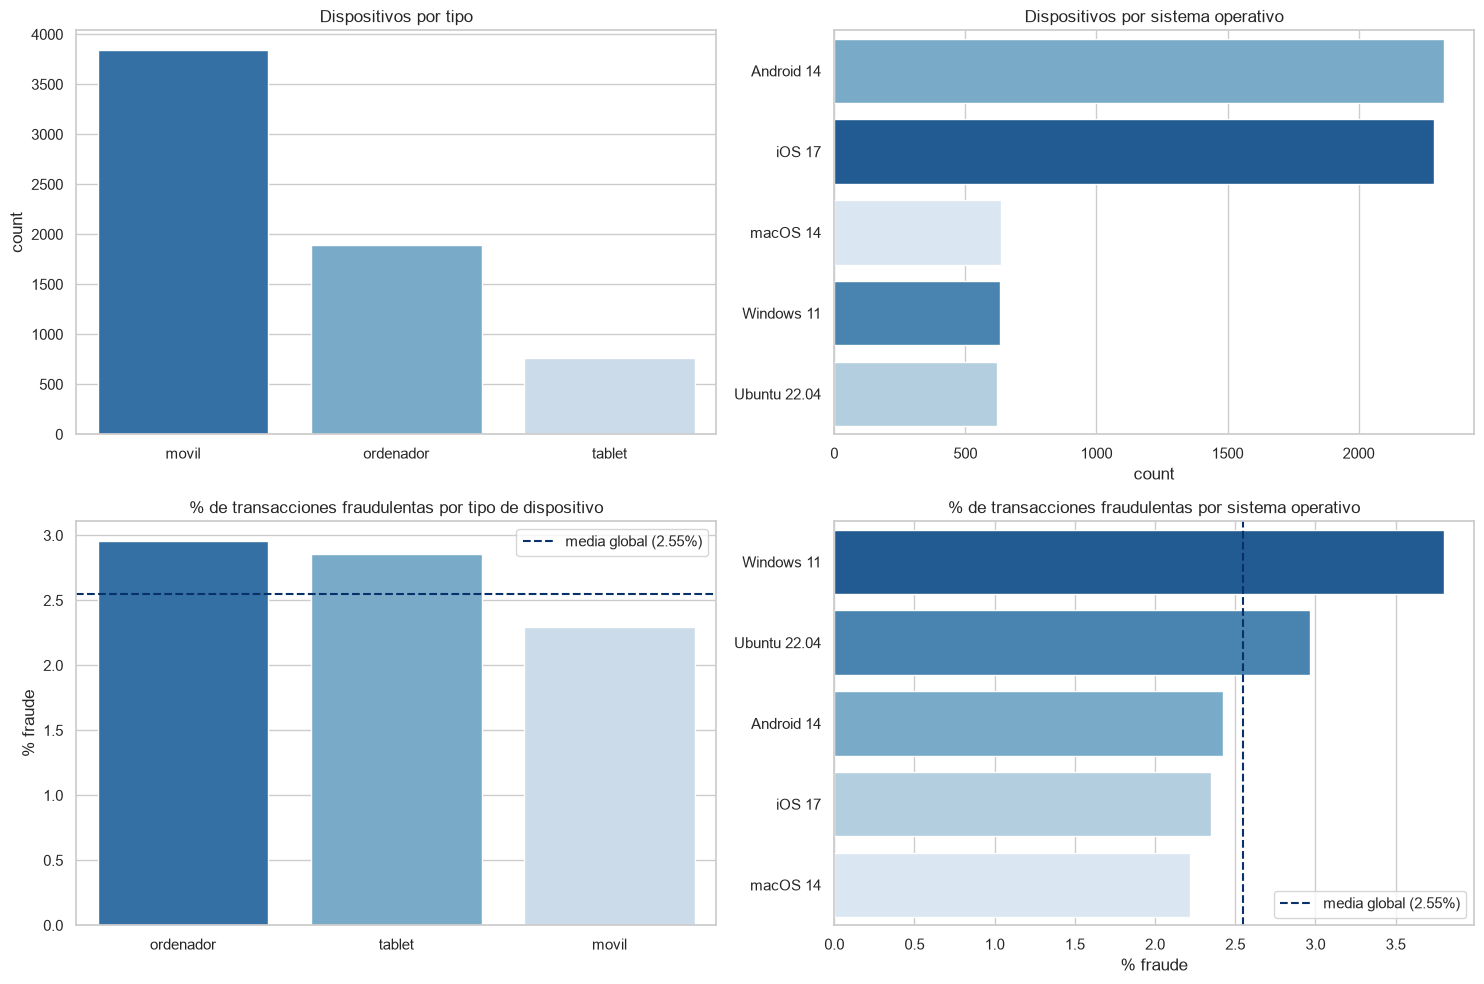

,tipo,n_transacciones,n_fraudes,tasa_fraude
0,ordenador,8753,259,2.96
1,tablet,3602,103,2.86
2,movil,18494,424,2.29


In [15]:
df_disp = client.query_df("SELECT dispositivo_id, tipo, sistema_operativo FROM dispositivo")

fraude_disp = client.query_df("""
    SELECT d.tipo, d.sistema_operativo,
           count() AS n_transacciones,
           countIf(t.es_fraude = 1) AS n_fraudes
    FROM transaccion t
    JOIN dispositivo d ON t.dispositivo_id = d.dispositivo_id
    GROUP BY d.tipo, d.sistema_operativo
""")

def tasa_fraude(df, col):
    agg = df.groupby(col)[["n_transacciones", "n_fraudes"]].sum()
    agg["tasa_fraude"] = agg["n_fraudes"] / agg["n_transacciones"] * 100
    return agg.sort_values("tasa_fraude", ascending=False).reset_index()

tasa_tipo = tasa_fraude(fraude_disp, "tipo")
tasa_so = tasa_fraude(fraude_disp, "sistema_operativo")
tasa_global = fraude_disp["n_fraudes"].sum() / fraude_disp["n_transacciones"].sum() * 100

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=df_disp, x="tipo", hue="tipo", palette=AZULES, legend=False,
              order=df_disp["tipo"].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title("Dispositivos por tipo")
axes[0, 0].set_xlabel("")

sns.countplot(data=df_disp, y="sistema_operativo", hue="sistema_operativo", palette=AZULES, legend=False,
              order=df_disp["sistema_operativo"].value_counts().index, ax=axes[0, 1])
axes[0, 1].set_title("Dispositivos por sistema operativo")
axes[0, 1].set_ylabel("")

sns.barplot(data=tasa_tipo, x="tipo", y="tasa_fraude", hue="tipo", palette=AZULES, legend=False, ax=axes[1, 0])
axes[1, 0].axhline(tasa_global, color="#08306b", linestyle="--", label=f"media global ({tasa_global:.2f}%)")
axes[1, 0].set_title("% de transacciones fraudulentas por tipo de dispositivo")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("% fraude")
axes[1, 0].legend()

sns.barplot(data=tasa_so, y="sistema_operativo", x="tasa_fraude", hue="sistema_operativo", palette=AZULES, legend=False, ax=axes[1, 1])
axes[1, 1].axvline(tasa_global, color="#08306b", linestyle="--", label=f"media global ({tasa_global:.2f}%)")
axes[1, 1].set_title("% de transacciones fraudulentas por sistema operativo")
axes[1, 1].set_xlabel("% fraude")
axes[1, 1].set_ylabel("")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

tasa_tipo.round(2)

Solo aparecen pagos online, porque los de datáfono no tienen dispositivo del cliente. Las diferencias entre tipos son pequeñas: ordenador 2,96 %, tablet 2,86 % y móvil 2,29 %. El tipo de dispositivo o el sistema operativo no distinguen el fraude. Lo que sí importa es si el dispositivo es nuevo para el cliente o si lo usan varios clientes distintos (los estafadores reutilizan su dispositivo contra varias víctimas); esas variables se calculan en el feature engineering del hito 3.

## 5. Sesion

### 5.1 VPN/proxy e intentos de login

En una sesión normal proxy_vpn debería ser falso y num_intentos_login igual a 1. Arriba está el reparto de las dos variables y abajo el porcentaje de sesiones que acaban en alguna transacción de fraude (con el join entre sesion y transaccion), comparado con la media global.

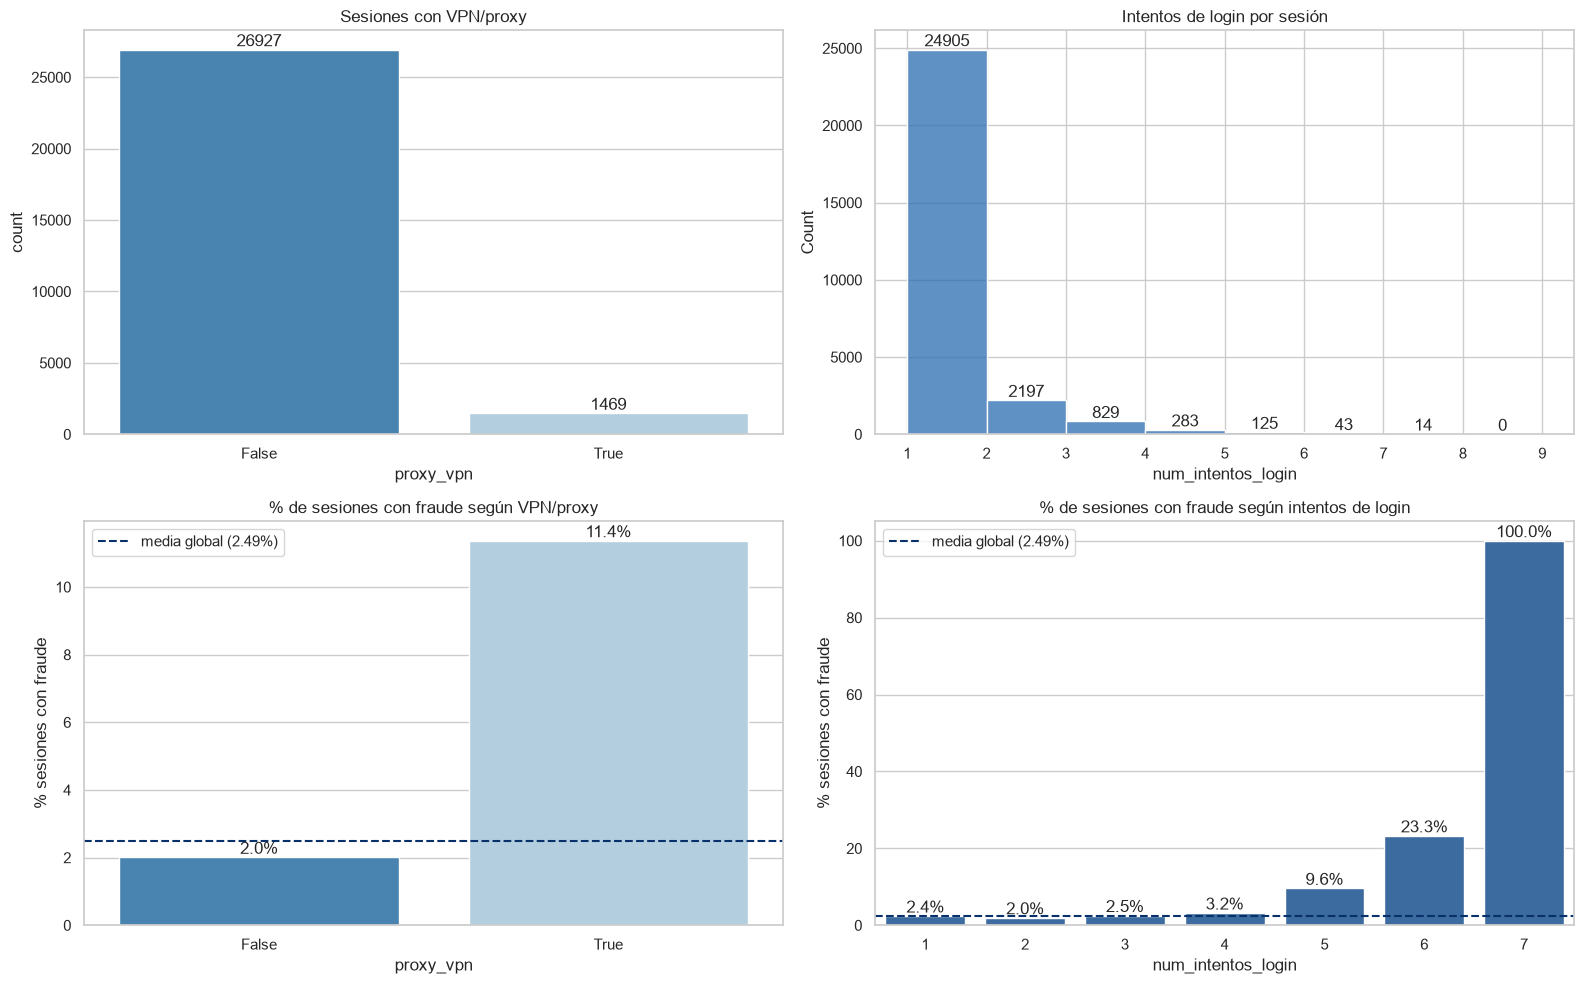

% sesiones con VPN/proxy: 5.17%
% sesiones con fraude (global): 2.49%



,num_intentos_login,n_sesiones,tasa_fraude
0,1,24905,2.41
1,2,2197,1.96
2,3,829,2.53
3,4,283,3.18
4,5,125,9.60
5,6,43,23.26
6,7,14,100.00


In [16]:
df_ses = client.query_df("""
    SELECT s.sesion_id, s.ip_pais, s.proxy_vpn, s.num_intentos_login, s.resultado_login,
           f.tiene_fraude
    FROM sesion s
    LEFT JOIN (SELECT sesion_id, max(toUInt8(es_fraude)) AS tiene_fraude
        FROM transaccion
        GROUP BY sesion_id ) f ON s.sesion_id = f.sesion_id
""")
df_ses["tiene_fraude"] = df_ses["tiene_fraude"].fillna(0).astype(int)
tasa_global_ses = df_ses["tiene_fraude"].mean() * 100

def tasa_por(df, col):
    agg = df.groupby(col)["tiene_fraude"].agg(n_sesiones="count", tasa_fraude="mean").reset_index()
    agg["tasa_fraude"] = agg["tasa_fraude"] * 100
    return agg

tasa_vpn = tasa_por(df_ses, "proxy_vpn")
tasa_login = tasa_por(df_ses, "num_intentos_login")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.countplot(data=df_ses, x="proxy_vpn", hue="proxy_vpn", palette=AZULES, legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Sesiones con VPN/proxy")
for cont in axes[0, 0].containers:
    axes[0, 0].bar_label(cont)

sns.histplot(df_ses["num_intentos_login"], bins=range(1, 10), color=AZUL, ax=axes[0, 1])
axes[0, 1].set_title("Intentos de login por sesión")
for cont in axes[0, 1].containers:
    axes[0, 1].bar_label(cont)

sns.barplot(data=tasa_vpn, x="proxy_vpn", y="tasa_fraude", hue="proxy_vpn", palette=AZULES, legend=False, ax=axes[1, 0])
axes[1, 0].axhline(tasa_global_ses, color="#08306b", linestyle="--", label=f"media global ({tasa_global_ses:.2f}%)")
axes[1, 0].set_title("% de sesiones con fraude según VPN/proxy")
axes[1, 0].set_ylabel("% sesiones con fraude")
axes[1, 0].legend()
for cont in axes[1, 0].containers:
    axes[1, 0].bar_label(cont, fmt="%.1f%%")

sns.barplot(data=tasa_login, x="num_intentos_login", y="tasa_fraude", color=AZUL, ax=axes[1, 1])
axes[1, 1].axhline(tasa_global_ses, color="#08306b", linestyle="--", label=f"media global ({tasa_global_ses:.2f}%)")
axes[1, 1].set_title("% de sesiones con fraude según intentos de login")
axes[1, 1].set_ylabel("% sesiones con fraude")
axes[1, 1].legend()
for cont in axes[1, 1].containers:
    axes[1, 1].bar_label(cont, fmt="%.1f%%")

plt.tight_layout()
plt.show()

print(f"% sesiones con VPN/proxy: {df_ses['proxy_vpn'].mean() * 100:.2f}%")
print(f"% sesiones con fraude (global): {tasa_global_ses:.2f}%\n")
tasa_login.round(2)

El 5,17 % de las sesiones usa VPN o proxy, y en ellas la tasa de fraude es del 11,37 %, unas 4,6 veces la media: es una señal útil pero no perfecta, porque hay usuarios legítimos que usan VPN. Con los intentos de login pasa algo parecido: con 1 o 2 intentos la tasa está en torno a la media (2,41 % y 1,96 %), con 4 sube al 3,18 %, con 5 al 9,60 % y con 6 al 23,26 %. Solo los 7 intentos son siempre fraude (14 sesiones). En la primera versión del dataset estas dos señales separaban el fraude al 100 %, lo que no era realista.

### 5.2 Países más frecuentes 

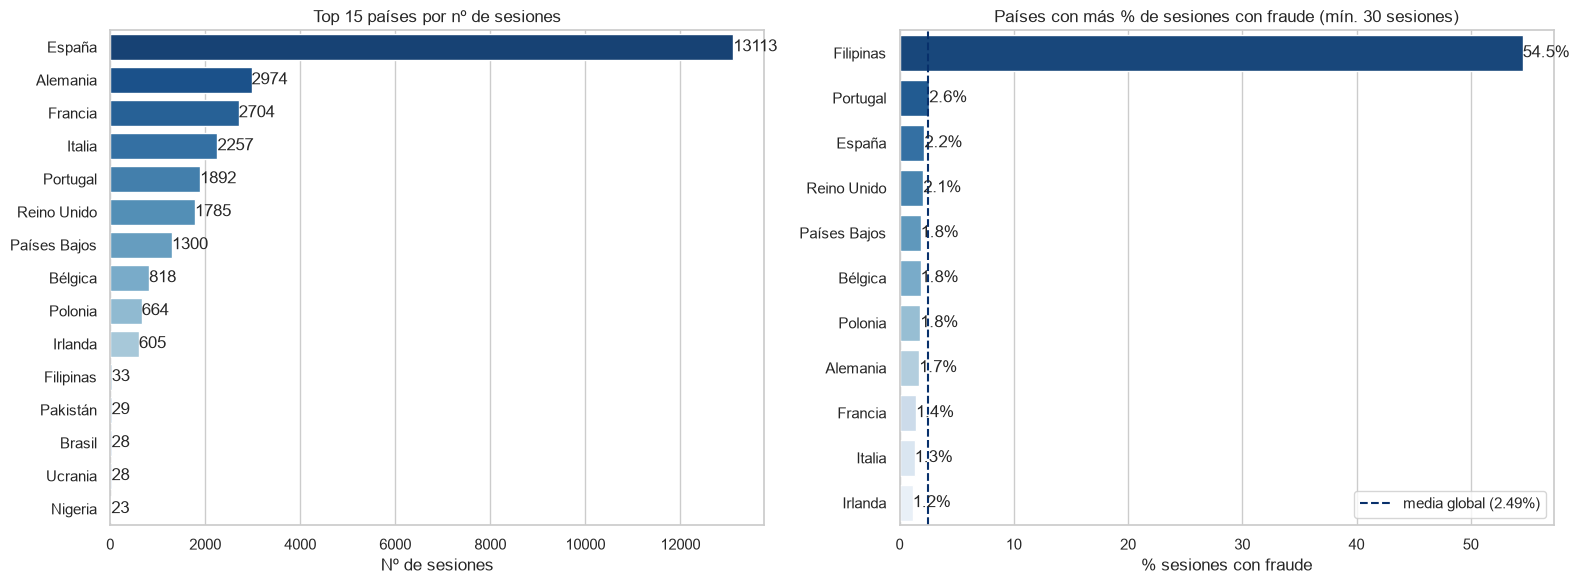

Nº de países distintos: 22



,grupo_pais,n_sesiones,tasa_fraude
0,resto,143,55.24
1,top 15,28253,2.23


In [17]:
top_paises = df_ses["ip_pais"].value_counts().head(15)

MIN_SESIONES = 30  
tasa_pais = tasa_por(df_ses, "ip_pais")
tasa_pais_top = (tasa_pais[tasa_pais["n_sesiones"] >= MIN_SESIONES]
                 .sort_values("tasa_fraude", ascending=False).head(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=top_paises.values, y=top_paises.index, hue=top_paises.index, palette=AZULES, legend=False, ax=axes[0])
axes[0].set_title("Top 15 países por nº de sesiones")
axes[0].set_xlabel("Nº de sesiones")
axes[0].set_ylabel("")
for cont in axes[0].containers:
    axes[0].bar_label(cont)

sns.barplot(data=tasa_pais_top, x="tasa_fraude", y="ip_pais", hue="ip_pais", palette=AZULES, legend=False, ax=axes[1])
axes[1].axvline(tasa_global_ses, color="#08306b", linestyle="--", label=f"media global ({tasa_global_ses:.2f}%)")
axes[1].set_title(f"Países con más % de sesiones con fraude (mín. {MIN_SESIONES} sesiones)")
axes[1].set_xlabel("% sesiones con fraude")
axes[1].set_ylabel("")
axes[1].legend()
for cont in axes[1].containers:
    axes[1].bar_label(cont, fmt="%.1f%%")

plt.tight_layout()
plt.show()

df_ses["grupo_pais"] = df_ses["ip_pais"].isin(top_paises.index).map({True: "top 15", False: "resto"})
print(f"Nº de países distintos: {df_ses['ip_pais'].nunique()}\n")
tasa_por(df_ses, "grupo_pais").round(2)


Hay 22 países distintos en ip_pais. Los 15 más frecuentes acumulan 28.253 sesiones con un 2,23 % de fraude, y las 143 sesiones del resto de países tienen un 55,24 %. Es una señal fuerte, pero no perfecta: casi la mitad de esas sesiones son legítimas, porque el 0,5 % de las compras normales se simula desde un país poco habitual. Los clientes que viajan no influyen aquí: solo se conectan desde los 10 países europeos habituales, que ya están entre los 15 más frecuentes.

## 6. metodo_pago

### 6.1 Tipo y entidad emisora

Arriba, el reparto de tarjetas entre crédito y débito y por entidad emisora. Abajo, el porcentaje de transacciones fraudulentas según el tipo de tarjeta y la entidad, comparado con la media global.

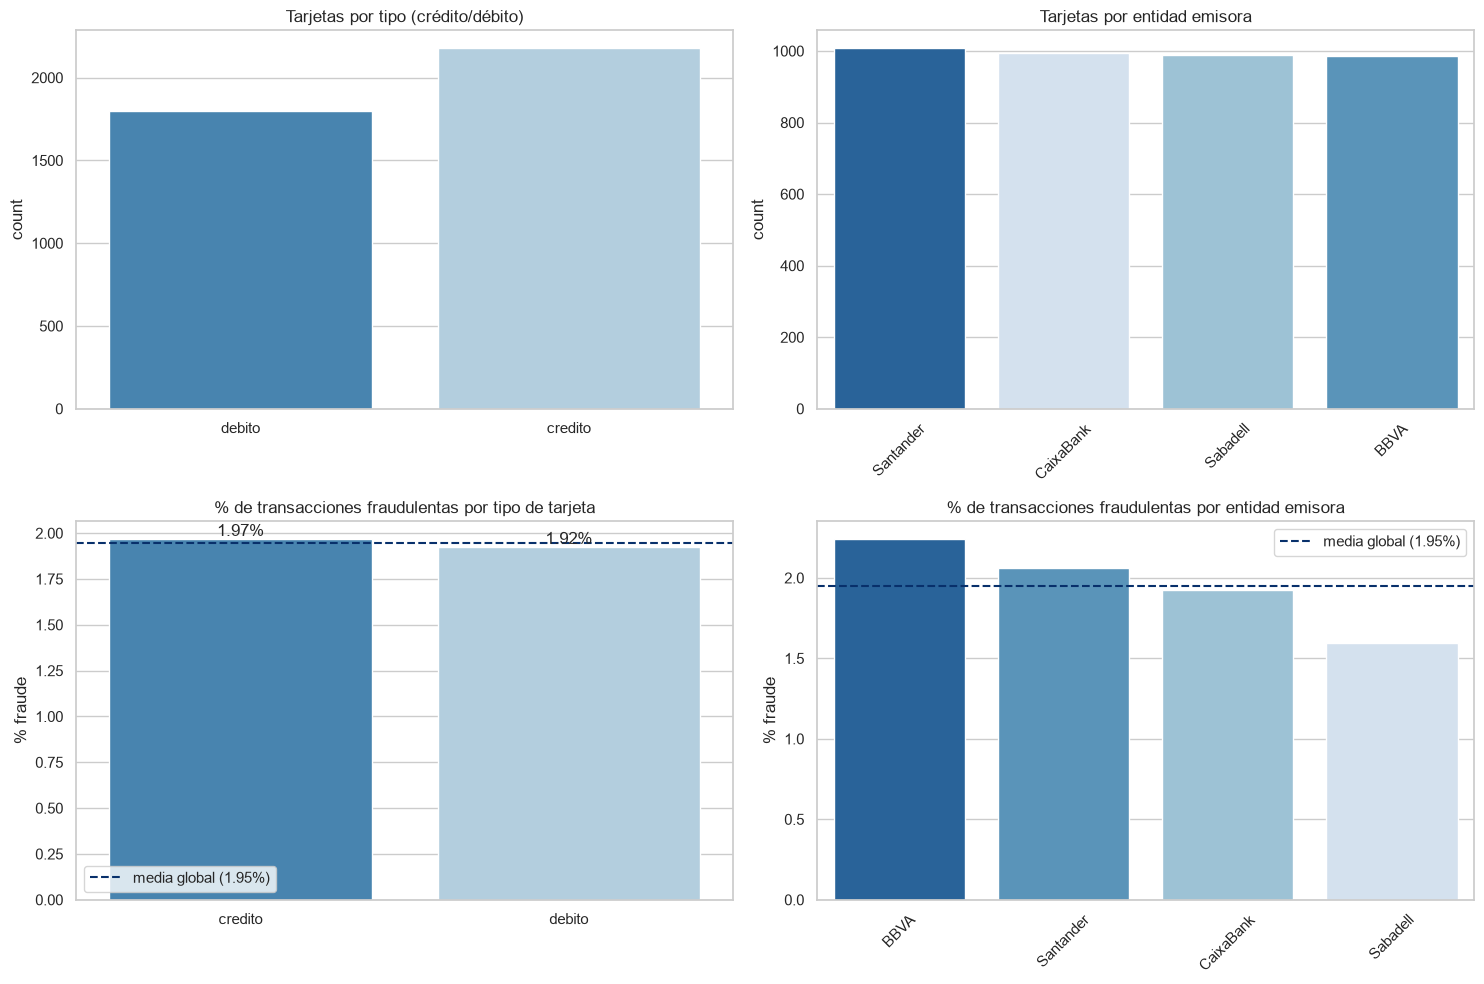

,tipo,n_transacciones,n_fraudes,tasa_fraude
0,credito,23507,462,1.97
1,debito,16856,324,1.92


In [18]:
df_metodo = client.query_df("SELECT metodo_id, cliente_id, tipo, entidad_emisora, limite_credito, estado FROM metodo_pago")

fraude_metodo = client.query_df("""
    SELECT m.tipo, m.entidad_emisora,
           count() AS n_transacciones,
           countIf(t.es_fraude = 1) AS n_fraudes
    FROM transaccion t
    JOIN metodo_pago m ON t.metodo_id = m.metodo_id
    GROUP BY m.tipo, m.entidad_emisora
""")

tasa_tarjeta = tasa_fraude(fraude_metodo, "tipo")
tasa_entidad = tasa_fraude(fraude_metodo, "entidad_emisora")
tasa_global_txn = fraude_metodo["n_fraudes"].sum() / fraude_metodo["n_transacciones"].sum() * 100

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=df_metodo, x="tipo", hue="tipo", palette=AZULES, legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Tarjetas por tipo (crédito/débito)")
axes[0, 0].set_xlabel("")

sns.countplot(data=df_metodo, x="entidad_emisora", hue="entidad_emisora", palette=AZULES, legend=False,
              order=df_metodo["entidad_emisora"].value_counts().index, ax=axes[0, 1])
axes[0, 1].set_title("Tarjetas por entidad emisora")
axes[0, 1].set_xlabel("")
axes[0, 1].tick_params(axis="x", rotation=45)

sns.barplot(data=tasa_tarjeta, x="tipo", y="tasa_fraude", hue="tipo", palette=AZULES, legend=False, ax=axes[1, 0])
axes[1, 0].axhline(tasa_global_txn, color="#08306b", linestyle="--", label=f"media global ({tasa_global_txn:.2f}%)")
axes[1, 0].set_title("% de transacciones fraudulentas por tipo de tarjeta")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("% fraude")
axes[1, 0].legend()
for cont in axes[1, 0].containers:
    axes[1, 0].bar_label(cont, fmt="%.2f%%")

sns.barplot(data=tasa_entidad, x="entidad_emisora", y="tasa_fraude", hue="entidad_emisora", palette=AZULES, legend=False, ax=axes[1, 1])
axes[1, 1].axhline(tasa_global_txn, color="#08306b", linestyle="--", label=f"media global ({tasa_global_txn:.2f}%)")
axes[1, 1].set_title("% de transacciones fraudulentas por entidad emisora")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("% fraude")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

tasa_tarjeta.round(2)

El tipo de tarjeta apenas influye: crédito 1,97 % y débito 1,92 %. Las entidades emisoras también están todas cerca de la media (entre el 1,59 % de Sabadell y el 2,24 % de BBVA).

### 6.2 Límite de crédito

Solo tiene sentido en las tarjetas de crédito (en débito limite_credito es nulo). A la izquierda está la distribución del límite. A la derecha, el importe de cada transacción como porcentaje del límite de su tarjeta, separado por clase. En los casos de bust_out el importe llega al 85-98 % del límite, zona marcada en el gráfico.

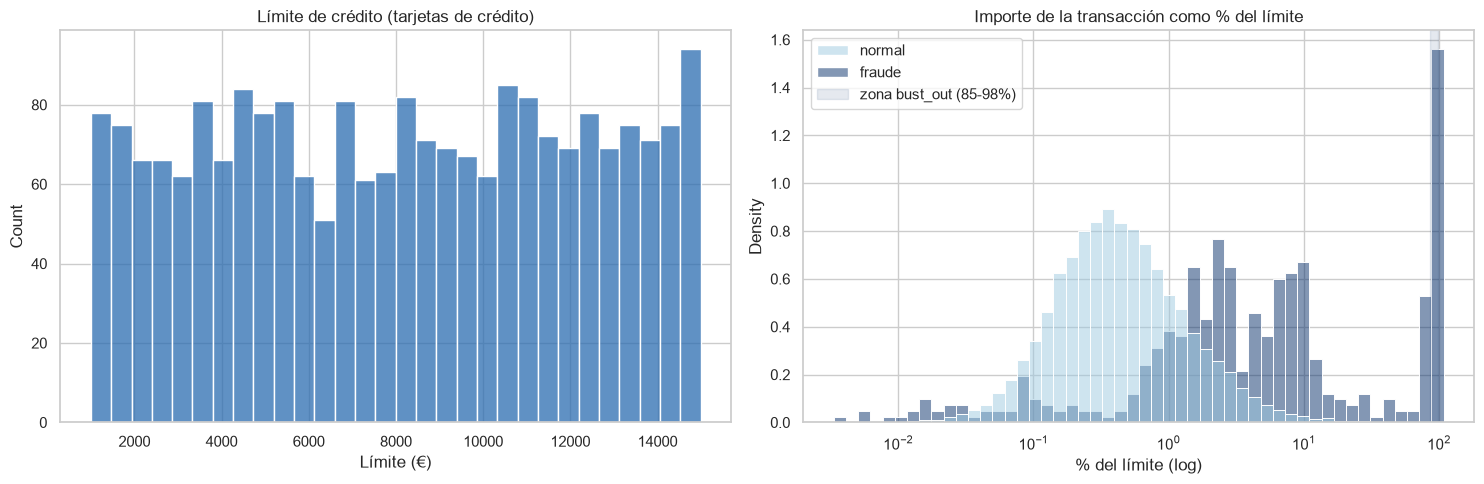

count     2176.00
mean      8100.54
std       4101.29
min       1001.00
25%       4553.00
50%       8215.50
75%      11654.75
max      14986.00 

Transacciones por encima del 85% del límite:
clase
fraude    87
normal     1


In [19]:
creditos = df_metodo[df_metodo["tipo"] == "credito"].copy()
creditos["limite_credito"] = creditos["limite_credito"].astype(float)

uso_limite = client.query_df("""
    SELECT t.transaccion_id, t.cantidad, m.limite_credito,
           if(t.es_fraude = 1, 'fraude', 'normal') AS clase
    FROM transaccion t
    JOIN metodo_pago m ON t.metodo_id = m.metodo_id
    WHERE m.tipo = 'credito'
""")
uso_limite[["cantidad", "limite_credito"]] = uso_limite[["cantidad", "limite_credito"]].astype(float)
uso_limite["pct_limite"] = uso_limite["cantidad"] / uso_limite["limite_credito"] * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(creditos["limite_credito"], bins=30, color=AZUL, ax=axes[0])
axes[0].set_title("Límite de crédito (tarjetas de crédito)")
axes[0].set_xlabel("Límite (€)")

sns.histplot(data=uso_limite, x="pct_limite", hue="clase", hue_order=["normal", "fraude"], palette=CLASES,
             stat="density", common_norm=False, bins=50, log_scale=True, ax=axes[1])
axes[1].axvspan(85, 98, color="#08306b", alpha=0.1, label="zona bust_out (85-98%)")
axes[1].set_title("Importe de la transacción como % del límite")
axes[1].set_xlabel("% del límite (log)")
axes[1].legend(handles=axes[1].get_legend().legend_handles + [axes[1].patches[-1]],
               labels=["normal", "fraude", "zona bust_out (85-98%)"])

plt.tight_layout()
plt.show()

print(creditos["limite_credito"].describe().round(2).to_string(), "\n")
print("Transacciones por encima del 85% del límite:")
print(uso_limite[uso_limite["pct_limite"] >= 85]["clase"].value_counts().to_string())


El límite de crédito va de 1.001 € a 14.986 €, con una media de 8.101 €. De las 88 transacciones que superan el 85 % del límite, 87 son fraude (bust-out) y 1 es una compra grande legítima. El importe como porcentaje del límite es una señal muy buena para este patrón, aunque es poco frecuente.

## 7. Comercio y Canal_pago 

### 7.1 Comercios por categoría de negocio y canales por tipo
Arriba, el reparto de comercios por categoría y de canales por tipo. Abajo, el porcentaje de transacciones fraudulentas en cada categoría y tipo de canal, comparado con la media global.

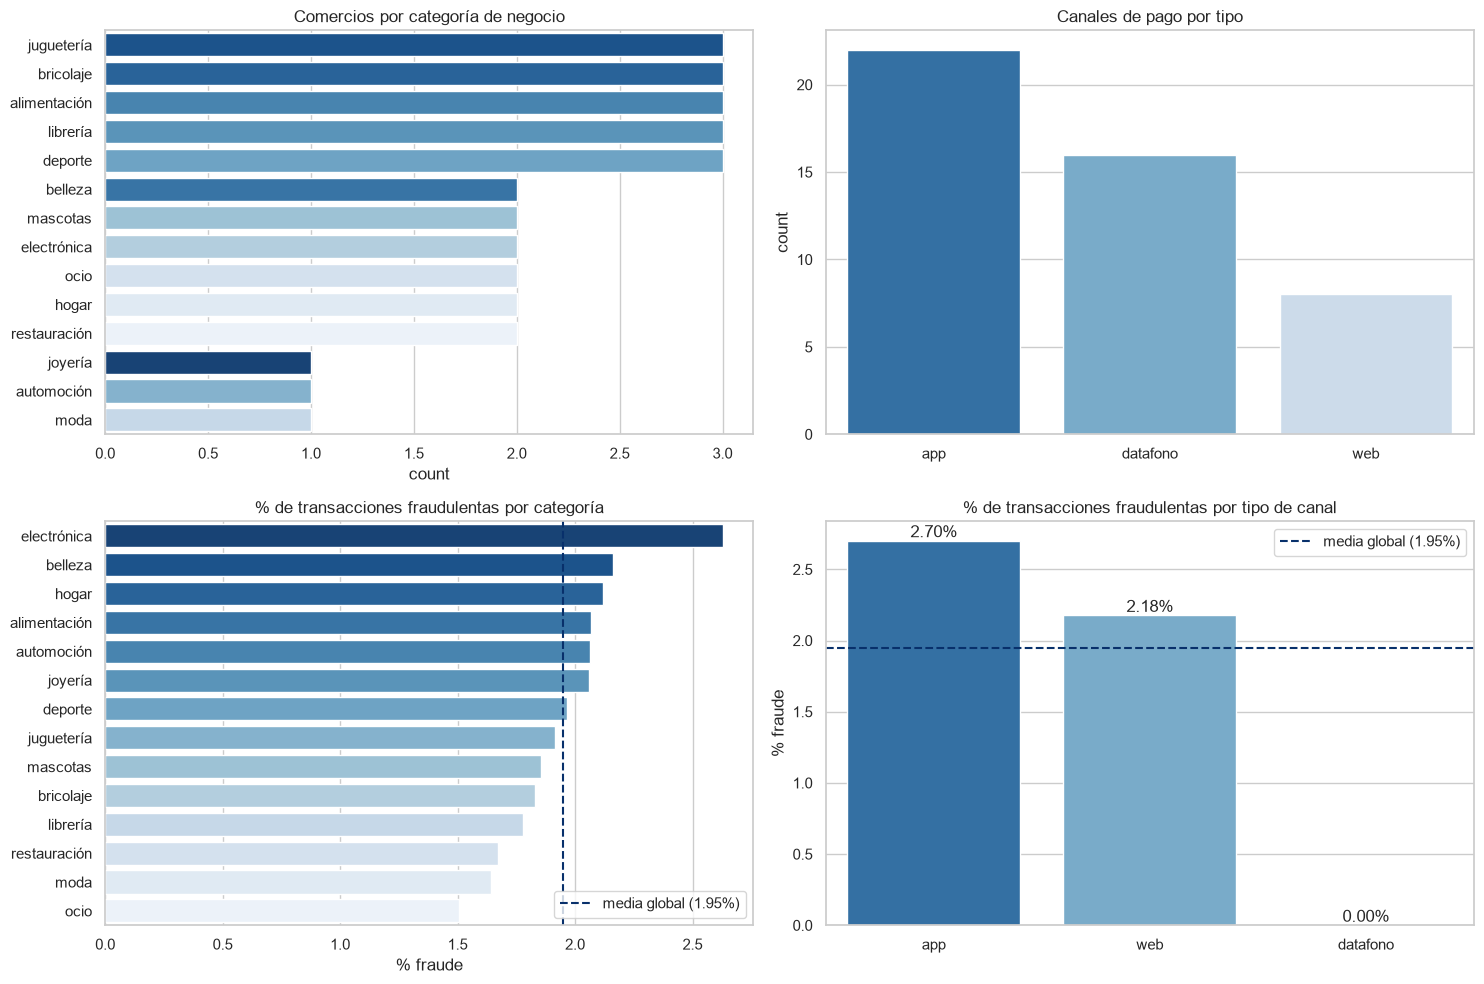

,tipo_canal,n_transacciones,n_fraudes,tasa_fraude
0,app,21844,590,2.70
1,web,9005,196,2.18
2,datafono,9514,0,0.00


In [20]:
df_com = client.query_df("SELECT comercio_id, categoria_negocio, pais FROM comercio")
df_can = client.query_df("SELECT canal_id, comercio_id, tipo FROM canal_pago")

fraude_comercio = client.query_df("""
    SELECT c.categoria_negocio, cp.tipo AS tipo_canal,
           count() AS n_transacciones,
           countIf(t.es_fraude = 1) AS n_fraudes
    FROM transaccion t
    JOIN canal_pago cp ON t.canal_id = cp.canal_id
    JOIN comercio c ON cp.comercio_id = c.comercio_id
    GROUP BY c.categoria_negocio, cp.tipo
""")

tasa_categoria = tasa_fraude(fraude_comercio, "categoria_negocio")
tasa_canal = tasa_fraude(fraude_comercio, "tipo_canal")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=df_com, y="categoria_negocio", hue="categoria_negocio", palette=AZULES, legend=False,
              order=df_com["categoria_negocio"].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title("Comercios por categoría de negocio")
axes[0, 0].set_ylabel("")

sns.countplot(data=df_can, x="tipo", hue="tipo", palette=AZULES, legend=False,
              order=df_can["tipo"].value_counts().index, ax=axes[0, 1])
axes[0, 1].set_title("Canales de pago por tipo")
axes[0, 1].set_xlabel("")

sns.barplot(data=tasa_categoria, y="categoria_negocio", x="tasa_fraude", hue="categoria_negocio",
            palette=AZULES, legend=False, ax=axes[1, 0])
axes[1, 0].axvline(tasa_global_txn, color="#08306b", linestyle="--", label=f"media global ({tasa_global_txn:.2f}%)")
axes[1, 0].set_title("% de transacciones fraudulentas por categoría")
axes[1, 0].set_xlabel("% fraude")
axes[1, 0].set_ylabel("")
axes[1, 0].legend()

sns.barplot(data=tasa_canal, x="tipo_canal", y="tasa_fraude", hue="tipo_canal",
            palette=AZULES, legend=False, ax=axes[1, 1])
axes[1, 1].axhline(tasa_global_txn, color="#08306b", linestyle="--", label=f"media global ({tasa_global_txn:.2f}%)")
axes[1, 1].set_title("% de transacciones fraudulentas por tipo de canal")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("% fraude")
axes[1, 1].legend()
for cont in axes[1, 1].containers:
    axes[1, 1].bar_label(cont, fmt="%.2f%%")

plt.tight_layout()
plt.show()

tasa_canal.round(2)


El canal datáfono no tiene fraude (0 %), porque todos los patrones de fraude generados son de pago online. Entre app (2,70 %) y web (2,18 %) la diferencia es pequeña. Por categoría, la tasa va del 1,51 % (ocio) al 2,63 % (electrónica), sin ninguna categoría que destaque de verdad. En la primera versión del dataset había pagos por datáfono hechos desde móviles; ahora un pago presencial no tiene dispositivo ni sesión, que es lo coherente.

### 7.2 Comercios por país y país de la IP
A la izquierda, el número de comercios por país. En el centro, el porcentaje de transacciones fraudulentas según el país del comercio. A la derecha, la comparación entre transacciones en las que el país de la IP coincide con el país del cliente y en las que no. Se compara con el país del cliente y no con el del comercio porque lo sospechoso es que el cliente se conecte desde un país que no es el suyo (señal típica de account takeover).

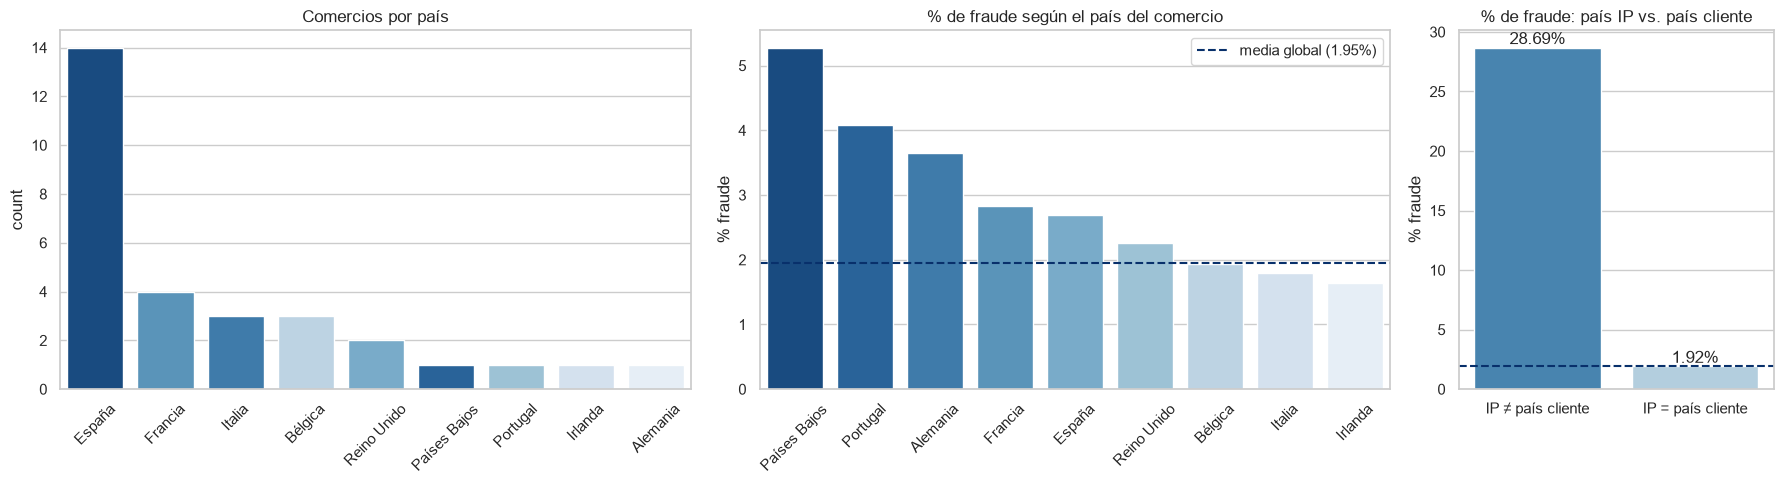

,mismo_pais,n_transacciones,n_fraudes,tasa_fraude
0,IP ≠ país cliente,725,208,28.69
1,IP = país cliente,30124,578,1.92


In [21]:
fraude_pais_com = client.query_df("""
    SELECT c.pais AS pais_comercio, s.ip_pais, cl.pais AS pais_cliente,
           count() AS n_transacciones,
           countIf(t.es_fraude = 1) AS n_fraudes
    FROM transaccion t
    JOIN canal_pago cp ON t.canal_id = cp.canal_id
    JOIN comercio c ON cp.comercio_id = c.comercio_id
    JOIN sesion s ON t.sesion_id = s.sesion_id
    JOIN cliente cl ON s.cliente_id = cl.cliente_id
    GROUP BY c.pais, s.ip_pais, cl.pais
""")
fraude_pais_com["mismo_pais"] = (fraude_pais_com["pais_cliente"] == fraude_pais_com["ip_pais"]).map(
    {True: "IP = país cliente", False: "IP ≠ país cliente"})

tasa_pais_com = tasa_fraude(fraude_pais_com, "pais_comercio")
tasa_mismo_pais = tasa_fraude(fraude_pais_com, "mismo_pais")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={"width_ratios": [2, 2, 1]})

sns.countplot(data=df_com, x="pais", hue="pais", palette=AZULES, legend=False,
              order=df_com["pais"].value_counts().index, ax=axes[0])
axes[0].set_title("Comercios por país")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=tasa_pais_com, x="pais_comercio", y="tasa_fraude", hue="pais_comercio",
            palette=AZULES, legend=False, ax=axes[1])
axes[1].axhline(tasa_global_txn, color="#08306b", linestyle="--", label=f"media global ({tasa_global_txn:.2f}%)")
axes[1].set_title("% de fraude según el país del comercio")
axes[1].set_xlabel("")
axes[1].set_ylabel("% fraude")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

sns.barplot(data=tasa_mismo_pais, x="mismo_pais", y="tasa_fraude", hue="mismo_pais",
            palette=AZULES, legend=False, ax=axes[2])
axes[2].axhline(tasa_global_txn, color="#08306b", linestyle="--")
axes[2].set_title("% de fraude: país IP vs. país cliente")
axes[2].set_xlabel("")
axes[2].set_ylabel("% fraude")
for cont in axes[2].containers:
    axes[2].bar_label(cont, fmt="%.2f%%")

plt.tight_layout()
plt.show()

tasa_mismo_pais.round(2)

Cuando el país de la IP es distinto al del cliente, la tasa de fraude sube al 28,69 %, frente al 1,92 % cuando coincide (unas 15 veces más).

### 7.3 Top comercios por transacciones e importe

A nivel de comercio individual. A la izquierda, los 15 con más transacciones. A la derecha, los 15 con mayor porcentaje de transacciones fraudulentas, para ver si el fraude se concentra en algún comercio concreto.

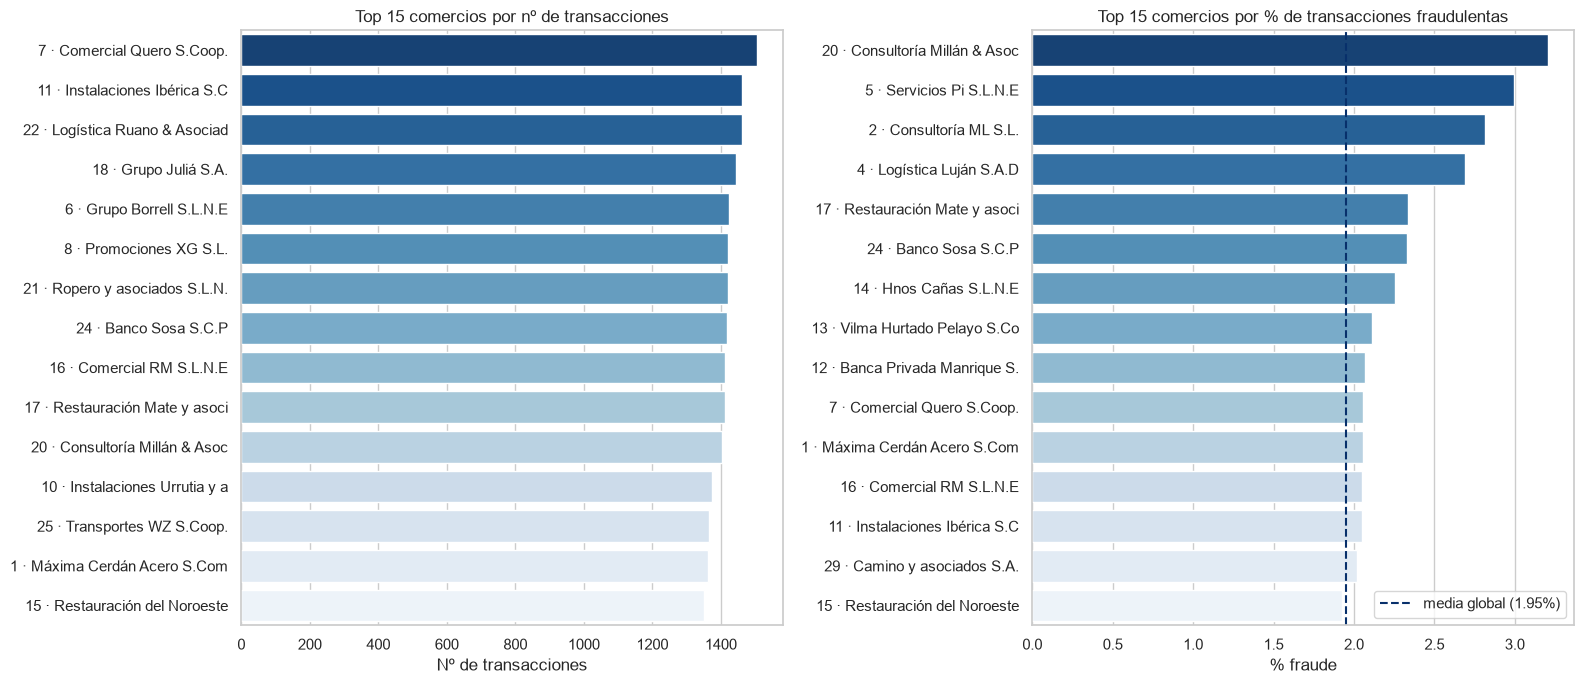

Comercios: 30
Transacciones por comercio: entre 1,169 y 1,506
Importe total por comercio: entre 59,763.81 € y 113,991.43 €
Tasa de fraude por comercio: entre 0.75 % y 3.21 %


,comercio_id,nombre,categoria_negocio,n_transacciones,importe_total,n_fraudes,tasa_fraude
1,7,Comercial Quero S.Coop.,librería,1506,104356.44,31,2.06
12,11,Instalaciones Ibérica S.Com.,deporte,1463,113991.43,30,2.05
29,22,Logística Ruano & Asociados S.Com.,moda,1463,106463.31,24,1.64
25,18,Grupo Juliá S.A.,deporte,1445,99391.33,22,1.52
27,6,Grupo Borrell S.L.N.E,librería,1425,85554.40,25,1.75
15,8,Promociones XG S.L.,belleza,1422,109849.22,24,1.69
11,21,Ropero y asociados S.L.N.E,alimentación,1421,92708.97,24,1.69
3,24,Banco Sosa S.C.P,hogar,1418,111828.64,33,2.33
17,16,Comercial RM S.L.N.E,electrónica,1413,71663.97,29,2.05
5,17,Restauración Mate y asociados S.L.,deporte,1412,105054.43,33,2.34


In [22]:
fraude_por_comercio = client.query_df("""
    SELECT c.comercio_id AS comercio_id, c.nombre AS nombre, c.categoria_negocio AS categoria_negocio,
           count() AS n_transacciones,
           round(sum(t.cantidad), 2) AS importe_total,
           countIf(t.es_fraude = 1) AS n_fraudes
    FROM transaccion t
    JOIN canal_pago cp ON t.canal_id = cp.canal_id
    JOIN comercio c ON cp.comercio_id = c.comercio_id
    GROUP BY c.comercio_id, c.nombre, c.categoria_negocio
""")
fraude_por_comercio["importe_total"] = fraude_por_comercio["importe_total"].astype(float)
fraude_por_comercio["tasa_fraude"] = fraude_por_comercio["n_fraudes"] / fraude_por_comercio["n_transacciones"] * 100
fraude_por_comercio["comercio"] = (fraude_por_comercio["comercio_id"].astype(str) + " · "
                                   + fraude_por_comercio["nombre"].str.slice(0, 25))
tasa_global_comercio = fraude_por_comercio["n_fraudes"].sum() / fraude_por_comercio["n_transacciones"].sum() * 100

top_txn = fraude_por_comercio.nlargest(15, "n_transacciones")
top_fraude = fraude_por_comercio.nlargest(15, "tasa_fraude")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=top_txn, y="comercio", x="n_transacciones", hue="comercio", palette=AZULES, legend=False, ax=axes[0])
axes[0].set_title("Top 15 comercios por nº de transacciones")
axes[0].set_xlabel("Nº de transacciones")
axes[0].set_ylabel("")

sns.barplot(data=top_fraude, y="comercio", x="tasa_fraude", hue="comercio", palette=AZULES, legend=False, ax=axes[1])
axes[1].axvline(tasa_global_comercio, color="#08306b", linestyle="--", label=f"media global ({tasa_global_comercio:.2f}%)")
axes[1].set_title("Top 15 comercios por % de transacciones fraudulentas")
axes[1].set_xlabel("% fraude")
axes[1].set_ylabel("")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Comercios: {len(fraude_por_comercio)}")
print(f"Transacciones por comercio: entre {fraude_por_comercio['n_transacciones'].min():,} y {fraude_por_comercio['n_transacciones'].max():,}")
print(f"Importe total por comercio: entre {fraude_por_comercio['importe_total'].min():,.2f} € y {fraude_por_comercio['importe_total'].max():,.2f} €")
print(f"Tasa de fraude por comercio: entre {fraude_por_comercio['tasa_fraude'].min():.2f} % y {fraude_por_comercio['tasa_fraude'].max():.2f} %")

(fraude_por_comercio.sort_values("n_transacciones", ascending=False)
 [["comercio_id", "nombre", "categoria_negocio", "n_transacciones", "importe_total", "n_fraudes", "tasa_fraude"]]
 .head(15).round(2))

Hay 30 comercios con un volumen parecido (entre 1.169 y 1.506 transacciones) y una tasa de fraude entre el 0,75 % y el 3,21 %. El fraude no se concentra en ningún comercio concreto: los comercios se eligen al azar en los casos de fraude, así que el comercio por sí solo no sirve como señal.

### 7.4 Tipos de fraude por tipo de canal

Cruce entre el tipo de fraude (transaccion.tipo_fraude) y el tipo de canal de la transacción. En el gráfico cada fila suma 100 %, así se ve en qué canales ocurre cada tipo de fraude; la tabla de debajo muestra los conteos. Se usa tipo_fraude y no la tabla alerta porque alerta no forma parte de los datos de origen: la rellenan las reglas y los modelos en los siguientes hitos.

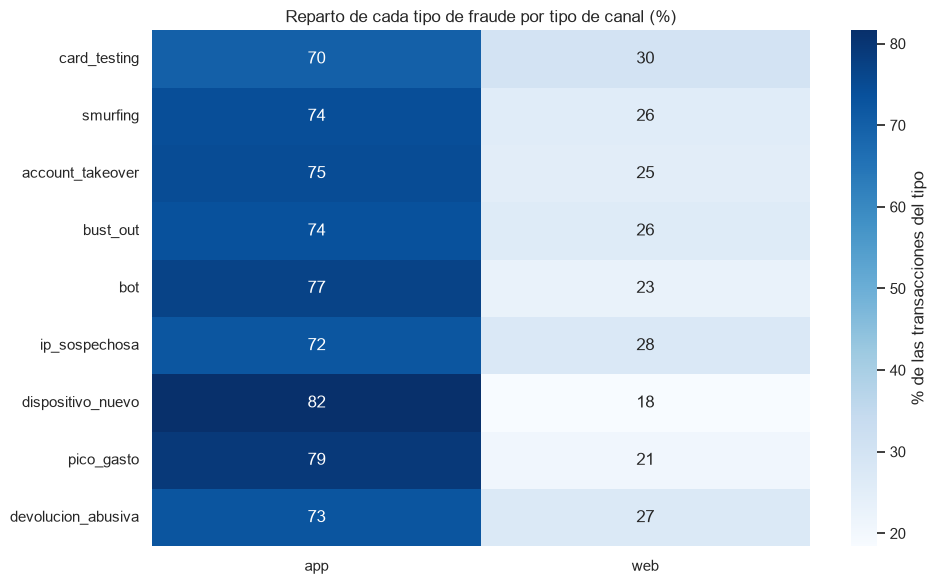

tipo_canal,app,web
tipo_fraude,,
card_testing,63.0,27.0
smurfing,67.0,23.0
account_takeover,65.0,22.0
bust_out,64.0,23.0
bot,67.0,20.0
ip_sospechosa,63.0,24.0
dispositivo_nuevo,71.0,16.0
pico_gasto,69.0,18.0
devolucion_abusiva,61.0,23.0


In [23]:
tipo_canal = client.query_df("""
    SELECT t.tipo_fraude AS tipo_fraude, cp.tipo AS tipo_canal, count() AS n
    FROM transaccion t
    JOIN canal_pago cp ON t.canal_id = cp.canal_id
    WHERE t.es_fraude = 1
    GROUP BY t.tipo_fraude, cp.tipo
""")

tabla = tipo_canal.pivot_table(index="tipo_fraude", columns="tipo_canal", values="n", fill_value=0)
tabla = tabla.loc[tabla.sum(axis=1).sort_values(ascending=False).index]
tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(tabla_pct, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "% de las transacciones del tipo"}, ax=ax)
ax.set_title("Reparto de cada tipo de fraude por tipo de canal (%)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

tabla

## 8. Tipos de fraude
### 8.1 Nº de transacciones por tipo de fraude
A la izquierda, el número de transacciones de cada tipo de fraude. A la derecha, su importe en escala logarítmica, para ver qué tipos mueven importes altos y cuáles no.

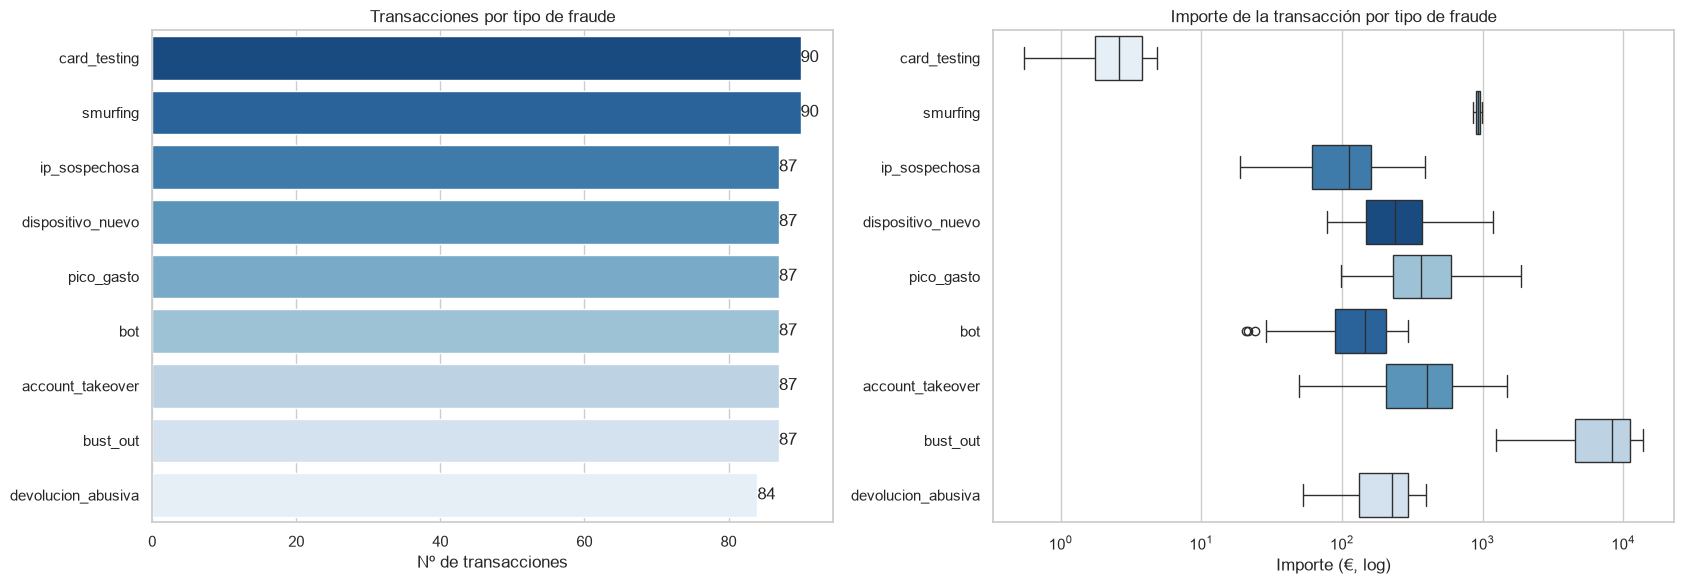

,tipo_fraude,n_transacciones,pct_del_fraude,mediana,media,importe_total
0,card_testing,90,11.5,2.58,2.71,243.67
1,smurfing,90,11.5,929.50,925.73,83315.45
2,ip_sospechosa,87,11.1,111.48,120.28,10464.43
3,dispositivo_nuevo,87,11.1,239.04,294.73,25641.82
4,pico_gasto,87,11.1,365.63,443.40,38575.72
5,bot,87,11.1,144.82,147.22,12807.82
6,account_takeover,87,11.1,403.34,463.92,40360.97
7,bust_out,87,11.1,8393.22,7969.38,693336.09
8,devolucion_abusiva,84,10.7,225.74,219.48,18436.19


In [24]:
fraude_por_tipo = client.query_df("""
    SELECT tipo_fraude, count() AS n_transacciones,
           round(count() * 100.0 / (SELECT countIf(es_fraude = 1) FROM transaccion), 1) AS pct_del_fraude
    FROM transaccion
    WHERE es_fraude = 1
    GROUP BY tipo_fraude
    ORDER BY n_transacciones DESC
""")

importe_tipo = client.query_df("SELECT tipo_fraude, cantidad FROM transaccion WHERE es_fraude = 1")
importe_tipo["cantidad"] = importe_tipo["cantidad"].astype(float)
ORDEN_TIPO = fraude_por_tipo["tipo_fraude"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

sns.barplot(data=fraude_por_tipo, x="n_transacciones", y="tipo_fraude", hue="tipo_fraude",
            order=ORDEN_TIPO, palette=AZULES, legend=False, ax=axes[0])
axes[0].set_title("Transacciones por tipo de fraude")
axes[0].set_xlabel("Nº de transacciones")
axes[0].set_ylabel("")
for cont in axes[0].containers:
    axes[0].bar_label(cont)

sns.boxplot(data=importe_tipo, x="cantidad", y="tipo_fraude", hue="tipo_fraude",
            order=ORDEN_TIPO, palette=AZULES, legend=False, log_scale=True, ax=axes[1])
axes[1].set_title("Importe de la transacción por tipo de fraude")
axes[1].set_xlabel("Importe (€, log)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

resumen_tipo = importe_tipo.groupby("tipo_fraude")["cantidad"].agg(mediana="median", media="mean", importe_total="sum")
fraude_por_tipo.merge(resumen_tipo.round(2), on="tipo_fraude")

Hay 9 tipos de fraude con un reparto equilibrado (alrededor del 11 % cada uno). Los importes cambian mucho según el tipo: el card testing usa importes de unos 2-3 € (mediana 2,58 €), el smurfing se queda justo por debajo de 1.000 € (mediana 929,50 €) y el bust-out es el más caro (mediana de 8.393 €). Un modelo basado solo en importes altos se dejaría fuera el card testing y la IP sospechosa, que tienen importes normales o bajos.

### 8.2 Tabla alerta
El generador del dataset deja la tabla alerta vacía a propósito. En la primera versión del dataset las alertas se generaban junto al fraude: solo existían para transacciones fraudulentas y con una nota de riesgo fija por patrón, así que eran una copia de la etiqueta (*data leakage*). Ahora la tabla la rellenan las reglas de reglas_alerta.py (hito 2) y los modelos, y así se puede medir de verdad cuántos fraudes detectan y cuántos falsos positivos generan. Si este notebook se ejecuta después del pipeline completo (main.py), la tabla ya tiene las alertas de las reglas.

In [25]:
print(f"Filas en alerta: {client.command('SELECT count() FROM alerta')}")
print(f"Patrones definidos: {client.command('SELECT count() FROM patron')}")

Filas en alerta: 1621
Patrones definidos: 9


La tabla patron tiene los 9 patrones definidos, con su descripción y su condición: son la base de las reglas que generan las alertas.

## 9. Devolucion

Se comparan las devoluciones de compras normales con las de compras fraudulentas (es_fraude de la transacción). No se usa el campo tipo porque ahora solo indica si el reembolso es total o parcial, igual en las dos clases. Además del importe, se miran los días entre la compra y la devolución, cuántas devoluciones acumula cada cliente y el motivo, que son las señales típicas del abuso de devoluciones.

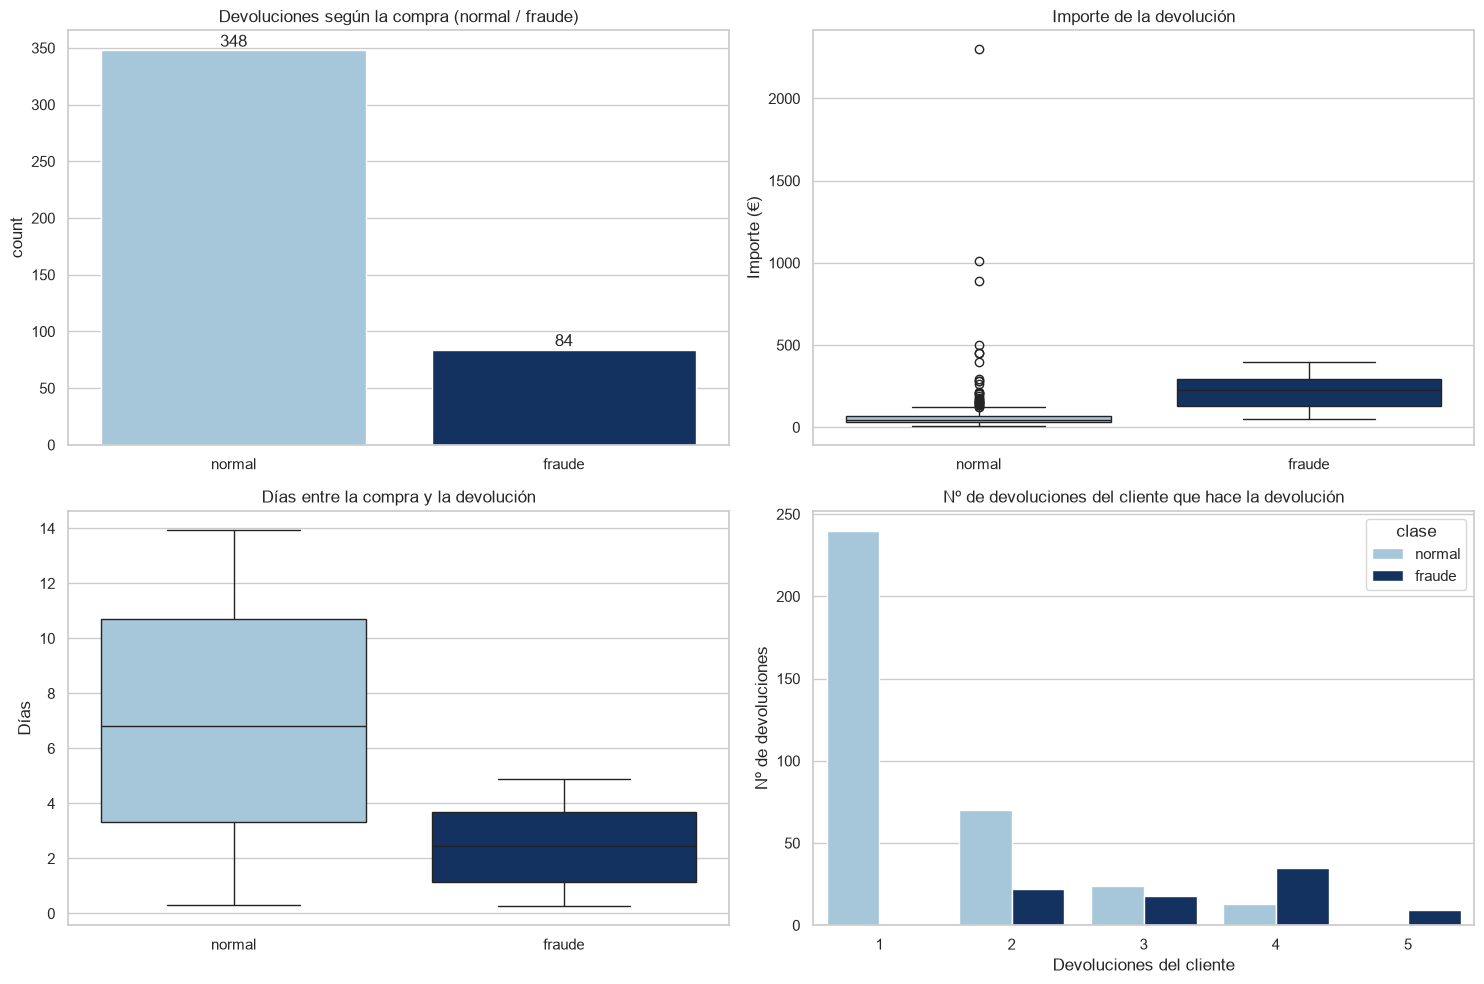

          n  importe_mediana  dias_mediana  clientes_distintos  media_devol_por_cliente
clase                                                                                  
normal  348            43.60          6.82                 288                     1.46
fraude   84           225.74          2.46                  28                     3.37 



clase,normal,fraude
motivo,,
cancelación del pedido,66,17
cargo duplicado,76,16
producto no conforme,67,20
producto no recibido,68,14
talla incorrecta,71,17


In [26]:
df_devol = client.query_df("""
    SELECT d.devolucion_id AS devolucion_id, d.tipo AS tipo, d.motivo AS motivo,
           d.importe AS importe, d.fecha AS fecha,
           t.timestamp AS fecha_compra, m.cliente_id AS cliente_id,
           if(t.es_fraude = 1, 'fraude', 'normal') AS clase
    FROM devolucion d
    JOIN transaccion t ON d.transaccion_id = t.transaccion_id
    JOIN metodo_pago m ON t.metodo_id = m.metodo_id
""")
df_devol["importe"] = df_devol["importe"].astype(float)
df_devol["dias_hasta_devolucion"] = (pd.to_datetime(df_devol["fecha"]) - pd.to_datetime(df_devol["fecha_compra"])).dt.total_seconds() / 86400

ORDEN_CLASE = ["normal", "fraude"]

# nº de devoluciones de cada cliente, asignado a cada devolución
df_devol["devol_del_cliente"] = df_devol.groupby("cliente_id")["devolucion_id"].transform("count")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=df_devol, x="clase", hue="clase", order=ORDEN_CLASE, palette=CLASES, legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Devoluciones según la compra (normal / fraude)")
axes[0, 0].set_xlabel("")
for cont in axes[0, 0].containers:
    axes[0, 0].bar_label(cont)

sns.boxplot(data=df_devol, x="clase", y="importe", hue="clase", order=ORDEN_CLASE, palette=CLASES, legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Importe de la devolución")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Importe (€)")

sns.boxplot(data=df_devol, x="clase", y="dias_hasta_devolucion", hue="clase", order=ORDEN_CLASE, palette=CLASES, legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Días entre la compra y la devolución")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Días")

sns.countplot(data=df_devol, x="devol_del_cliente", hue="clase", hue_order=ORDEN_CLASE, palette=CLASES, ax=axes[1, 1])
axes[1, 1].set_title("Nº de devoluciones del cliente que hace la devolución")
axes[1, 1].set_xlabel("Devoluciones del cliente")
axes[1, 1].set_ylabel("Nº de devoluciones")

plt.tight_layout()
plt.show()

resumen_devol = df_devol.groupby("clase").agg(
    n=("devolucion_id", "count"),
    importe_mediana=("importe", "median"),
    dias_mediana=("dias_hasta_devolucion", "median"),
    clientes_distintos=("cliente_id", "nunique"),
    media_devol_por_cliente=("devol_del_cliente", "mean"),
).loc[ORDEN_CLASE].round(2)
print(resumen_devol.to_string(), "\n")

pd.crosstab(df_devol["motivo"], df_devol["clase"])[ORDEN_CLASE]

Hay 432 devoluciones: 348 de compras normales y 84 de compras fraudulentas. Las de fraude tienen importes más altos (mediana de 225,74 € frente a 43,60 €) y se hacen antes (mediana de 2,5 días frente a 6,8). Además, los clientes de las devoluciones fraudulentas acumulan de media 3,4 devoluciones, frente a 1,5 en las normales: el abuso de devoluciones se simula como un mismo cliente que repite. El motivo no delata el fraude, porque los dos grupos usan los mismos motivos en proporciones parecidas (en la primera versión, todas las fraudulentas tenían un motivo propio). Solo se registran las devoluciones hechas hasta el final del periodo de datos.

## 10. Fraude vs. no fraude 

Comparación final entre las transacciones con es_fraude = 1 y el resto: cuántas hay de cada clase, cómo se distribuye el importe y cómo cambia el porcentaje de fraude según la hora del día. Después, una tabla que junta las señales que han salido en el resto del notebook, ordenadas según cuántas veces superan la tasa media de fraude.

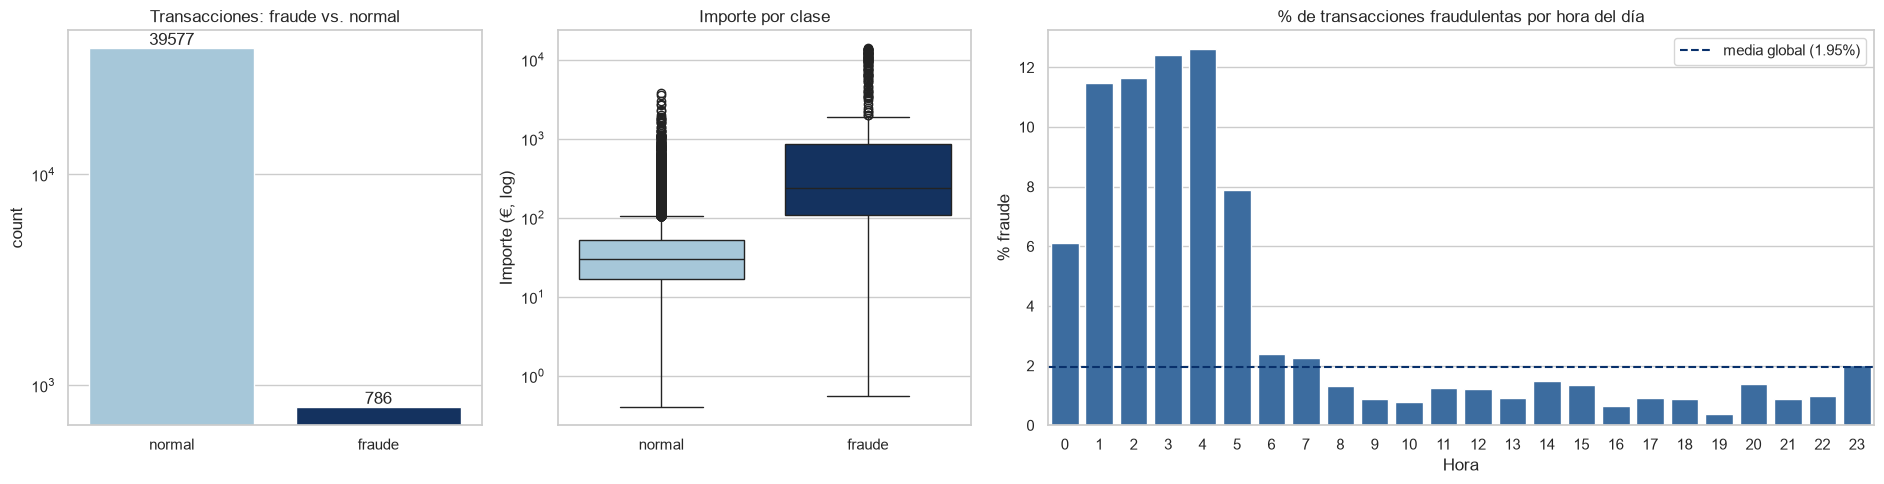

            n  mediana    media
clase                          
fraude    786   239.71  1174.53
normal  39577    29.70    45.97

Fraude entre las 0 y las 6 h: 47.8% (normales: 8.7%)
Hora con más fraude: 4 h -> 12.61% (6.5 veces la media)


In [27]:
df_comparativa = df_txn[["transaccion_id", "cantidad", "clase", "timestamp", "es_fraude"]].copy()
df_comparativa["hora"] = pd.to_datetime(df_comparativa["timestamp"]).dt.hour
df_comparativa["es_fraude"] = df_comparativa["es_fraude"].astype(int)

tasa_hora = df_comparativa.groupby("hora")["es_fraude"].mean().mul(100).reset_index(name="tasa_fraude")
tasa_global = df_comparativa["es_fraude"].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(19, 5), gridspec_kw={"width_ratios": [1, 1, 2]})

sns.countplot(data=df_comparativa, x="clase", hue="clase", order=["normal", "fraude"], palette=CLASES, legend=False, ax=axes[0])
axes[0].set_title("Transacciones: fraude vs. normal")
axes[0].set_yscale("log")
axes[0].set_xlabel("")
for cont in axes[0].containers:
    axes[0].bar_label(cont)

sns.boxplot(data=df_comparativa, x="clase", y="cantidad", hue="clase", order=["normal", "fraude"], palette=CLASES, legend=False, ax=axes[1])
axes[1].set_title("Importe por clase")
axes[1].set_yscale("log")
axes[1].set_xlabel("")
axes[1].set_ylabel("Importe (€, log)")

sns.barplot(data=tasa_hora, x="hora", y="tasa_fraude", color=AZUL, ax=axes[2])
axes[2].axhline(tasa_global, color="#08306b", linestyle="--", label=f"media global ({tasa_global:.2f}%)")
axes[2].set_title("% de transacciones fraudulentas por hora del día")
axes[2].set_xlabel("Hora")
axes[2].set_ylabel("% fraude")
axes[2].legend()

plt.tight_layout()
plt.show()

print(df_comparativa.groupby("clase")["cantidad"].agg(n="count", mediana="median", media="mean").round(2).to_string())

# cifras de la hora que se citan en el texto
madrugada = df_comparativa["hora"] < 6
pct_fraude_madrugada = madrugada[df_comparativa["es_fraude"] == 1].mean() * 100
pct_normal_madrugada = madrugada[df_comparativa["es_fraude"] == 0].mean() * 100
hora_max = tasa_hora.loc[tasa_hora["tasa_fraude"].idxmax()]
print(f"\nFraude entre las 0 y las 6 h: {pct_fraude_madrugada:.1f}% (normales: {pct_normal_madrugada:.1f}%)")
print(f"Hora con más fraude: {int(hora_max['hora'])} h -> {hora_max['tasa_fraude']:.2f}% "
      f"({hora_max['tasa_fraude'] / tasa_global:.1f} veces la media)")


In [28]:
senales = pd.DataFrame([
    {"señal": "Sesión con VPN/proxy", "nivel": "sesión",
     "n": df_ses["proxy_vpn"].sum(),
     "pct_fraude": df_ses.loc[df_ses["proxy_vpn"] == 1, "tiene_fraude"].mean() * 100,
     "media_global": tasa_global_ses},
    {"señal": "Más de 1 intento de login", "nivel": "sesión",
     "n": (df_ses["num_intentos_login"] > 1).sum(),
     "pct_fraude": df_ses.loc[df_ses["num_intentos_login"] > 1, "tiene_fraude"].mean() * 100,
     "media_global": tasa_global_ses},
    {"señal": "País IP ≠ país cliente", "nivel": "transacción",
     "n": tasa_mismo_pais.loc[tasa_mismo_pais["mismo_pais"] == "IP ≠ país cliente", "n_transacciones"].sum(),
     "pct_fraude": tasa_mismo_pais.loc[tasa_mismo_pais["mismo_pais"] == "IP ≠ país cliente", "tasa_fraude"].sum(),
     "media_global": tasa_global_txn},
    {"señal": "Importe ≥ 85% del límite", "nivel": "transacción",
     "n": (uso_limite["pct_limite"] >= 85).sum(),
     "pct_fraude": (uso_limite.loc[uso_limite["pct_limite"] >= 85, "clase"] == "fraude").mean() * 100,
     "media_global": tasa_global_txn},
    {"señal": "Importe > P99", "nivel": "transacción",
     "n": (df_txn["cantidad"] > CUTOFF).sum(),
     "pct_fraude": df_txn.loc[df_txn["cantidad"] > CUTOFF, "es_fraude"].astype(int).mean() * 100,
     "media_global": tasa_global_txn},
])
senales["veces_la_media"] = senales["pct_fraude"] / senales["media_global"]
senales.sort_values("veces_la_media", ascending=False).round(2)

,señal,nivel,n,pct_fraude,media_global,veces_la_media
3,Importe ≥ 85% del límite,transacción,88,98.86,1.95,50.77
4,Importe > P99,transacción,404,63.37,1.95,32.54
2,País IP ≠ país cliente,transacción,725,28.69,1.95,14.73
0,Sesión con VPN/proxy,sesión,1469,11.37,2.49,4.56
1,Más de 1 intento de login,sesión,3491,3.12,2.49,1.25


Hay 786 transacciones de fraude frente a 39.577 normales (1,95 %). El fraude tiene importes más altos (mediana de 239,71 € frente a 29,70 €), aunque el importe no basta por sí solo porque el card testing usa importes muy bajos. La hora del día es una señal clara: el 47,8 % del fraude ocurre entre las 0 y las 6 h, frente al 8,7 % de las transacciones normales. A las 4 de la madrugada, el 12,61 % de las transacciones son fraude, 6,5 veces la media.

La tabla de señales resume las variables más útiles: el importe cerca del límite multiplica por 51 la tasa media de fraude, el importe por encima del P99 por 33, la IP de otro país por 15, la VPN por 4,6 y más de un intento de login solo por 1,3. **Ninguna señal separa el fraude por sí sola**, así que en los siguientes hitos habrá que combinarlas con modelos de detección de anomalías.